# Notebook - Find best Drug compound for `Yersinia Pestis` bacteria

In this notebook, we demonstrate the use of MACAW embeddings to model binding affinity to a protein receptor of pharmacological interest. MACAW embeddings are then applied to identify promising candidate molecules in a custom virtual library.

In [80]:
import sys
import os

# Completely suppress stderr output
sys.stderr = open(os.devnull, 'w')

# Now import everything
import warnings
warnings.filterwarnings('ignore')

In [81]:
import os
import csv
import numpy as np
import pandas as pd


from sklearn.model_selection import KFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import r2_score

#Needed to show molecules
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole 
import seaborn as sns
from joblib import load

import sys
sys.path.append('../')

import macaw
print(macaw.__version__)
from macaw import *

import warnings
warnings.filterwarnings("ignore")

import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans']
matplotlib.rcParams['figure.dpi'] = 96
matplotlib.rcParams['savefig.dpi'] = 600

%run "./plotting.py"

1.0.1


In [82]:
%config InlineBackend.figure_format = 'retina'

## 1. Regression Target: pPotency

### 1.1 Data preparation

In [83]:
dataDir = '/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/'
modelBuildingDataDir = os.path.join(dataDir, 'modelBuildingData/')
resultsDir = os.path.join(dataDir, 'Results/')

In [84]:
allBacteriaData_chEMBL = pd.read_csv(modelBuildingDataDir + 'allBacteriaData_chEMBL_uM.csv')

In [85]:
allBacteriaData_chEMBL

,Unnamed: 0,molecule_chembl_id,smiles,molecular_formula,inchi_key,inchi,molecular_weight,type,standard_value,standard_units,...,ro5_violations,Target ChEMBL ID,Target Name,Target Organism,Virus,value_uM,pPotency,is_convertible_to_uM,potency_family,pPotencyMid
0,1,CHEMBL8,O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O,C17H18FN3O3,MYSWGUAQZAJSOK-UHFFFAOYSA-N,InChI=1S/C17H18FN3O3/c18-13-7-11-14(8-15(13)20...,331.350,Small molecule,0.250,ug.mL-1,...,0.000e+00,CHEMBL359,Bacillus subtilis,Bacillus subtilis,Bacillus_subtilisData_chEMBL_combined.csv,5.623e+05,0.250,True,MIC,0.250
1,2,CHEMBL606360,COc1ccc(C(=O)/C=C/c2cn(-c3ccccc3)nc2-c2ccc(Cl)...,C26H21ClN2O3,KEINEPLOMWOUNE-XNTDXEJSSA-N,InChI=1S/C26H21ClN2O3/c1-31-22-13-14-23(25(16-...,444.920,Small molecule,100.000,ug.mL-1,...,1.000,CHEMBL359,Bacillus subtilis,Bacillus subtilis,Bacillus_subtilisData_chEMBL_combined.csv,1.000e-94,100.000,True,MIC,100.000
2,3,CHEMBL4089761,NC[C@H]1O[C@H](O[C@H]2[C@H](O)[C@@H](O[C@H]3O[...,C40H59FN10O14,VETOBWPFYDUOPP-FFKZLMLRSA-N,InChI=1S/C40H59FN10O14/c41-21-9-19-24(51(18-1-...,922.970,Small molecule,1.500,ug.mL-1,...,3.000,CHEMBL359,Bacillus subtilis,Bacillus subtilis,Bacillus_subtilisData_chEMBL_combined.csv,3.162e+04,1.500,True,MIC,1.500
3,4,CHEMBL1241817,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)N/N=C/c1cccc(...,C16H12N6O5,DGJBCVGFPFQIOC-CAOOACKPSA-N,InChI=1S/C16H12N6O5/c23-16(19-17-8-11-2-1-3-13...,368.310,Small molecule,16.000,ug.mL-1,...,0.000e+00,CHEMBL359,Bacillus subtilis,Bacillus subtilis,Bacillus_subtilisData_chEMBL_combined.csv,1.000e-10,16.000,True,MIC,16.000
4,5,CHEMBL1242158,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)NN1C(=O)CSC1c...,C18H14ClN5O4S,SJWDBKWBFHCWPA-UHFFFAOYSA-N,InChI=1S/C18H14ClN5O4S/c19-13-3-1-11(2-4-13)18...,431.860,Small molecule,16.000,ug.mL-1,...,0.000e+00,CHEMBL359,Bacillus subtilis,Bacillus subtilis,Bacillus_subtilisData_chEMBL_combined.csv,1.000e-10,16.000,True,MIC,16.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163417,313296,CHEMBL4227290,CCCCCCCSSC(=S)N(CC)CC,C12H25NS3,LGZOHACUFLJANX-UHFFFAOYSA-N,InChI=1S/C12H25NS3/c1-4-7-8-9-10-11-15-16-12(1...,279.540,Small molecule,3.200e+04,nM,...,0.000e+00,CHEMBL614597,Yersinia pestis,Yersinia pestis,Yersinia_pestisData_chEMBL_combined.csv,32.000,4.495,True,MIC,4.495
163418,313298,CHEMBL1255631,CC(=O)NCCCC(=O)N[C@@H](Cc1ccccc1)C(=O)N1Cc2ccc...,C145H210N28O21,QNANZYFCKTWPTJ-WSPVJQGRSA-N,InChI=1S/C145H210N28O21/c1-93(174)154-76-36-65...,2.681e+03,Small molecule,4.660e+04,nM,...,NaN,CHEMBL614597,Yersinia pestis,Yersinia pestis,Yersinia_pestisData_chEMBL_combined.csv,46.600,4.332,True,MIC,4.332
163419,313304,CHEMBL5276443,CC(C)(CNc1ccc(C(N)=O)cn1)c1ccccc1,C16H19N3O,XVNKQYMDQJGTEQ-UHFFFAOYSA-N,"InChI=1S/C16H19N3O/c1-16(2,13-6-4-3-5-7-13)11-...",269.350,NaN,256.000,ug.mL-1,...,0.000e+00,CHEMBL614597,Yersinia pestis,Yersinia pestis,Yersinia_pestisData_chEMBL_combined.csv,1.000e-250,256.000,True,MIC,256.000
163420,313309,CHEMBL1916867,CSC(=S)N/N=C/c1ccccc1O,C9H10N2OS2,SATLYQNFXURMCO-UXBLZVDNSA-N,InChI=1S/C9H10N2OS2/c1-14-9(13)11-10-6-7-4-2-3...,226.330,Small molecule,4.000e+03,nM,...,0.000e+00,CHEMBL614597,Yersinia pestis,Yersinia pestis,Yersinia_pestisData_chEMBL_combined.csv,4.000,5.398,True,IC/EC,5.398


### Filter columns

In [86]:
allBacteriaData_chEMBL = allBacteriaData_chEMBL.filter(
    items=["molecule_chembl_id", "smiles", "value_uM", "pPotency", "Virus"]
)
allBacteriaData_chEMBL

,molecule_chembl_id,smiles,value_uM,pPotency,Virus
0,CHEMBL8,O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O,5.623e+05,0.250,Bacillus_subtilisData_chEMBL_combined.csv
1,CHEMBL606360,COc1ccc(C(=O)/C=C/c2cn(-c3ccccc3)nc2-c2ccc(Cl)...,1.000e-94,100.000,Bacillus_subtilisData_chEMBL_combined.csv
2,CHEMBL4089761,NC[C@H]1O[C@H](O[C@H]2[C@H](O)[C@@H](O[C@H]3O[...,3.162e+04,1.500,Bacillus_subtilisData_chEMBL_combined.csv
3,CHEMBL1241817,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)N/N=C/c1cccc(...,1.000e-10,16.000,Bacillus_subtilisData_chEMBL_combined.csv
4,CHEMBL1242158,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)NN1C(=O)CSC1c...,1.000e-10,16.000,Bacillus_subtilisData_chEMBL_combined.csv
...,...,...,...,...,...
163417,CHEMBL4227290,CCCCCCCSSC(=S)N(CC)CC,32.000,4.495,Yersinia_pestisData_chEMBL_combined.csv
163418,CHEMBL1255631,CC(=O)NCCCC(=O)N[C@@H](Cc1ccccc1)C(=O)N1Cc2ccc...,46.600,4.332,Yersinia_pestisData_chEMBL_combined.csv
163419,CHEMBL5276443,CC(C)(CNc1ccc(C(N)=O)cn1)c1ccccc1,1.000e-250,256.000,Yersinia_pestisData_chEMBL_combined.csv
163420,CHEMBL1916867,CSC(=S)N/N=C/c1ccccc1O,4.000,5.398,Yersinia_pestisData_chEMBL_combined.csv


### Remove the trailing 'Data_chEMBL_combined.csv' from each entry in the 'Virus' column

In [87]:
allBacteriaData_chEMBL['Virus'] = allBacteriaData_chEMBL['Virus'].str.replace('Data_chEMBL_combined.csv', '', regex=False)
allBacteriaData_chEMBL.rename(columns={'Virus': 'Bacteria'}, inplace=True)
allBacteriaData_chEMBL

,molecule_chembl_id,smiles,value_uM,pPotency,Bacteria
0,CHEMBL8,O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O,5.623e+05,0.250,Bacillus_subtilis
1,CHEMBL606360,COc1ccc(C(=O)/C=C/c2cn(-c3ccccc3)nc2-c2ccc(Cl)...,1.000e-94,100.000,Bacillus_subtilis
2,CHEMBL4089761,NC[C@H]1O[C@H](O[C@H]2[C@H](O)[C@@H](O[C@H]3O[...,3.162e+04,1.500,Bacillus_subtilis
3,CHEMBL1241817,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)N/N=C/c1cccc(...,1.000e-10,16.000,Bacillus_subtilis
4,CHEMBL1242158,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)NN1C(=O)CSC1c...,1.000e-10,16.000,Bacillus_subtilis
...,...,...,...,...,...
163417,CHEMBL4227290,CCCCCCCSSC(=S)N(CC)CC,32.000,4.495,Yersinia_pestis
163418,CHEMBL1255631,CC(=O)NCCCC(=O)N[C@@H](Cc1ccccc1)C(=O)N1Cc2ccc...,46.600,4.332,Yersinia_pestis
163419,CHEMBL5276443,CC(C)(CNc1ccc(C(N)=O)cn1)c1ccccc1,1.000e-250,256.000,Yersinia_pestis
163420,CHEMBL1916867,CSC(=S)N/N=C/c1ccccc1O,4.000,5.398,Yersinia_pestis


### Keep only data for `YersiniacPestis` bacteria

In [88]:
YersiniaPestisData_chEMBL = allBacteriaData_chEMBL[allBacteriaData_chEMBL['Bacteria'] == 'Yersinia_pestis']
YersiniaPestisData_chEMBL

,molecule_chembl_id,smiles,value_uM,pPotency,Bacteria
163235,CHEMBL2368935,CC(=O)NCCCC(=O)N[C@@H](Cc1ccccc1)C(=O)N1Cc2ccc...,196.000,3.708,Yersinia_pestis
163236,CHEMBL1255638,CC(=O)NCC(=O)N[C@@H](Cc1ccccc1)C(=O)N1Cc2ccccc...,220.000,3.658,Yersinia_pestis
163237,CHEMBL1255640,CC(=O)N[C@@H](CCCCN)C(=O)N[C@@H](CCCCN)C(=O)N[...,13.100,4.883,Yersinia_pestis
163238,CHEMBL1255643,CC(C)C[C@H](NC(=O)[C@@H](N)CCCCN)C(=O)N1Cc2ccc...,150.000,3.824,Yersinia_pestis
163239,CHEMBL1200699,C[C@H]1c2cccc(O)c2C(=O)C2=C(O)[C@]3(O)C(=O)C(C...,0.560,6.252,Yersinia_pestis
...,...,...,...,...,...
163417,CHEMBL4227290,CCCCCCCSSC(=S)N(CC)CC,32.000,4.495,Yersinia_pestis
163418,CHEMBL1255631,CC(=O)NCCCC(=O)N[C@@H](Cc1ccccc1)C(=O)N1Cc2ccc...,46.600,4.332,Yersinia_pestis
163419,CHEMBL5276443,CC(C)(CNc1ccc(C(N)=O)cn1)c1ccccc1,1.000e-250,256.000,Yersinia_pestis
163420,CHEMBL1916867,CSC(=S)N/N=C/c1ccccc1O,4.000,5.398,Yersinia_pestis


### Rename columns

In [89]:
YersiniaPestisData_chEMBL = YersiniaPestisData_chEMBL.rename(columns={
    "molecule_chembl_id": "compound_id",
    "smiles": "Smiles",
    #"pPotencyMid" : "pPotency",
})
YersiniaPestisData_chEMBL.head()

,compound_id,Smiles,value_uM,pPotency,Bacteria
163235,CHEMBL2368935,CC(=O)NCCCC(=O)N[C@@H](Cc1ccccc1)C(=O)N1Cc2ccc...,196.000,3.708,Yersinia_pestis
163236,CHEMBL1255638,CC(=O)NCC(=O)N[C@@H](Cc1ccccc1)C(=O)N1Cc2ccccc...,220.000,3.658,Yersinia_pestis
163237,CHEMBL1255640,CC(=O)N[C@@H](CCCCN)C(=O)N[C@@H](CCCCN)C(=O)N[...,13.100,4.883,Yersinia_pestis
163238,CHEMBL1255643,CC(C)C[C@H](NC(=O)[C@@H](N)CCCCN)C(=O)N1Cc2ccc...,150.000,3.824,Yersinia_pestis
163239,CHEMBL1200699,C[C@H]1c2cccc(O)c2C(=O)C2=C(O)[C@]3(O)C(=O)C(C...,0.560,6.252,Yersinia_pestis


### Add `ID` column to left

In [90]:
YersiniaPestisData_chEMBL.insert(0, 'ID', range(1, len(YersiniaPestisData_chEMBL) + 1))
YersiniaPestisData_chEMBL.head()

,ID,compound_id,Smiles,value_uM,pPotency,Bacteria
163235,1,CHEMBL2368935,CC(=O)NCCCC(=O)N[C@@H](Cc1ccccc1)C(=O)N1Cc2ccc...,196.000,3.708,Yersinia_pestis
163236,2,CHEMBL1255638,CC(=O)NCC(=O)N[C@@H](Cc1ccccc1)C(=O)N1Cc2ccccc...,220.000,3.658,Yersinia_pestis
163237,3,CHEMBL1255640,CC(=O)N[C@@H](CCCCN)C(=O)N[C@@H](CCCCN)C(=O)N[...,13.100,4.883,Yersinia_pestis
163238,4,CHEMBL1255643,CC(C)C[C@H](NC(=O)[C@@H](N)CCCCN)C(=O)N1Cc2ccc...,150.000,3.824,Yersinia_pestis
163239,5,CHEMBL1200699,C[C@H]1c2cccc(O)c2C(=O)C2=C(O)[C@]3(O)C(=O)C(C...,0.560,6.252,Yersinia_pestis


### Add another filer to keep only these columns: `ID`, `compound_id`,	`Smiles`, `pPotency`, `BacteriaClassifier`

In [91]:
YersiniaPestisData_chEMBL = YersiniaPestisData_chEMBL.filter(
    items=["ID", "compound_id", "Smiles", "pPotency", "BacteriaClassifier"]
)
YersiniaPestisData_chEMBL.head()

,ID,compound_id,Smiles,pPotency
163235,1,CHEMBL2368935,CC(=O)NCCCC(=O)N[C@@H](Cc1ccccc1)C(=O)N1Cc2ccc...,3.708
163236,2,CHEMBL1255638,CC(=O)NCC(=O)N[C@@H](Cc1ccccc1)C(=O)N1Cc2ccccc...,3.658
163237,3,CHEMBL1255640,CC(=O)N[C@@H](CCCCN)C(=O)N[C@@H](CCCCN)C(=O)N[...,4.883
163238,4,CHEMBL1255643,CC(C)C[C@H](NC(=O)[C@@H](N)CCCCN)C(=O)N1Cc2ccc...,3.824
163239,5,CHEMBL1200699,C[C@H]1c2cccc(O)c2C(=O)C2=C(O)[C@]3(O)C(=O)C(C...,6.252


### Remove NaN, -ve and unphysical (>12) values in `pPotency` before cross-validation

| Range (pPotency) | IC₅₀/EC₅₀ (in M)          | Interpretation                                | Action              |
| ---------------- | -------------------- | --------------------------------------------- | ------------------- |
| **0–3**   | > 1×10⁻³ M (millimolar)     | Very weak or inactive compounds               | Drop         |
| **3–10**  | 1×10⁻³ – 1×10⁻¹⁰ M          | Normal drug-like activity range               | **Keep**                |
| **10–12** | 1×10⁻¹⁰ – 1×10⁻¹² M         | Extremely potent but still physically possible | **Keep (with caution)** |
| **>12**   | < 1×10⁻¹² M (picomolar–femto) | Physically unrealistic / likely data error     | Drop                |



In [92]:
print("Original shape:", YersiniaPestisData_chEMBL.shape)

YersiniaPestisData_chEMBL = YersiniaPestisData_chEMBL[YersiniaPestisData_chEMBL['pPotency'].notna() 
    & (YersiniaPestisData_chEMBL['pPotency'] > 0) & (YersiniaPestisData_chEMBL['pPotency'] < 12)]

print("Shape after cleaning 'pPotency' value:", YersiniaPestisData_chEMBL.shape)

Original shape: (187, 4)
Shape after cleaning 'pPotency' value: (153, 4)


### Remove duplicate compounds using Compute median potency per (Smiles, Bacteria) pair

In [93]:
duplicates = YersiniaPestisData_chEMBL.duplicated(subset=['Smiles'])
print("Remaining duplicates:", duplicates.sum())

Remaining duplicates: 61


In [94]:
YersiniaPestisData_chEMBL.to_csv(os.path.join(modelBuildingDataDir, "YersiniaPestisData_chEMBL_MLready.csv"), index=False)

### Clip first 1000 rows from the data set for fast testing

### Train ML Model

In [95]:
# df = YersiniaPestisData_chEMBL
Y = YersiniaPestisData_chEMBL.pPotency
smiles = YersiniaPestisData_chEMBL.Smiles

In [96]:
print(len(smiles))

153


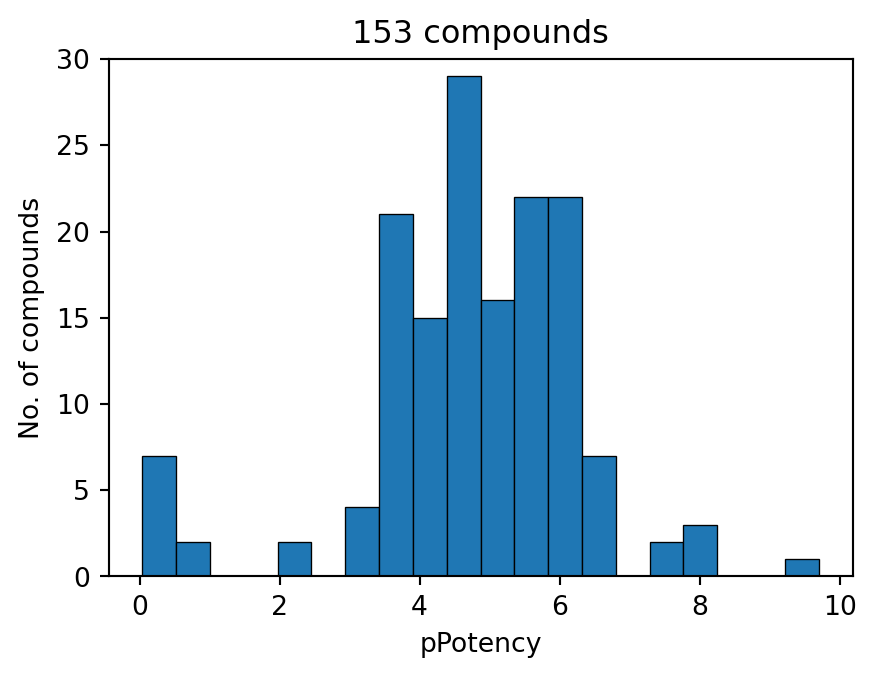

In [97]:
plot_histogram(Y, xlabel="pPotency")

Define the partitions for cross-validation.

In [98]:
num_of_partitions = 10
kf = KFold(n_splits=num_of_partitions, shuffle=True, random_state=42)

Define hyperparameters for SVR:

In [99]:
param_grid = {
    'C': [1, 5, 7, 10, 30, 50, 100, 300, 500], 
    'epsilon': [0.1, 0.3, 1, 3, 5, 10, 20],
    'kernel': ['rbf']
}

Define MACAW embedding:

In [108]:
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=100, 
    random_state=39
)


After cleaning NaN values, reset the indices

In [109]:
valid_mask = Y.notna()
smiles = smiles[valid_mask].reset_index(drop=True)  
Y = Y[valid_mask].reset_index(drop=True)            

print(f"Cleaned data has: {len(smiles)} samples")
print(f"Y index: {Y.index[:10].tolist()}")  

Cleaned data has: 153 samples
Y index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


### Create directory to save plot

In [110]:
save_path = resultsDir + 'YersiniaPestis/YersiniaPestis_CV_testOnly.svg'
os.makedirs(os.path.dirname(save_path), exist_ok=True)

### ML predictions with Test only results

In [111]:
%%time

Y_cv_pred = []
Y_obs = []

i = 1
for train_index, val_index in kf.split(smiles):
    print(f"Partition {i}/{num_of_partitions}")
    i+=1
    smi_train , smi_val = smiles.iloc[train_index], smiles.iloc[val_index]
    y_train , y_val = Y[train_index], Y[val_index]
    
    # Compute MACAW embeddings
    mcw.fit(smi_train, y_train)
    
    X_train = mcw.transform(smi_train)
    X_val = mcw.transform(smi_val)
    
    # Train the SVR model
    # Optimize hyperparameters
    grid = GridSearchCV(SVR(), param_grid, cv=5, refit=True, n_jobs=4, verbose=0, scoring='neg_mean_absolute_error', pre_dispatch='2*n_jobs')

    grid.fit(X_train, y_train)
#     print(grid.best_params_)
    
    # Test set predictions
    y_cv_pred = grid.predict(X_val)
    
    # Save corresponding validation instances
    Y_cv_pred.extend(y_cv_pred)
    Y_obs.extend(y_val)

Partition 1/10
Partition 2/10
Partition 3/10
Partition 4/10
Partition 5/10
Partition 6/10
Partition 7/10
Partition 8/10
Partition 9/10
Partition 10/10
CPU times: user 10.7 s, sys: 153 ms, total: 10.9 s
Wall time: 13.3 s


Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/YersiniaPestis/YersiniaPestis_CV_testOnly.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/YersiniaPestis/YersiniaPestis_CV_testOnly.png


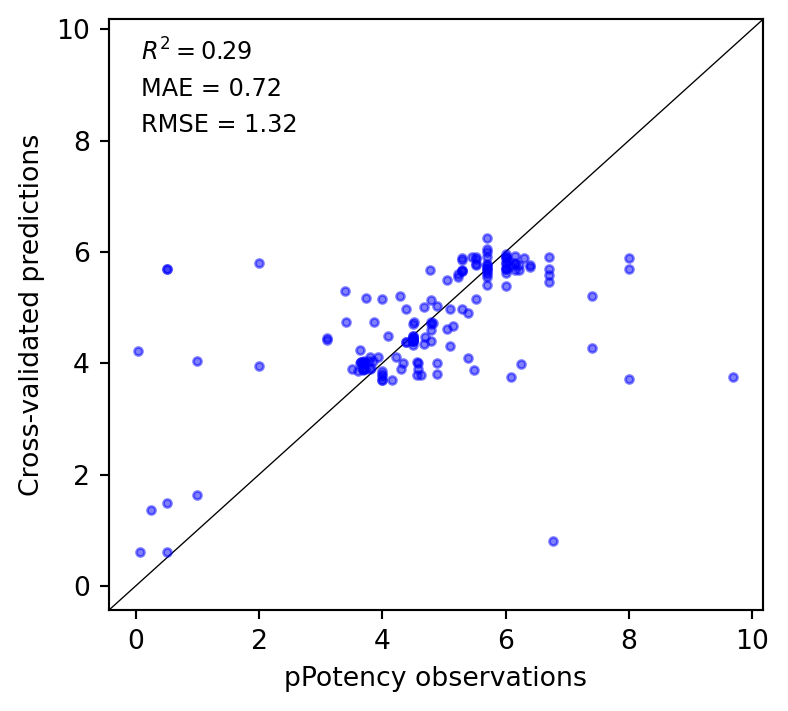

In [112]:
# Parity plot
parity_plot(x=Y_obs,
            y=Y_cv_pred, 
            xlabel="pPotency observations", 
            ylabel="Cross-validated predictions",
            savetitle=resultsDir + 'YersiniaPestis/YersiniaPestis_CV_testOnly.svg',
            save_formats=['svg', 'png'])  # Specify both formats

### ML predictions with Train + Test results

In [113]:
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from joblib import Parallel, delayed
from copy import deepcopy

# ===== DEFINE FUNCTION FOR SINGLE FOLD =====
def process_fold(fold_id, train_index, test_index, smiles, Y, mcw, param_grid, num_partitions):
    """Process a single CV fold"""
    print(f"Partition {fold_id}/{num_partitions}")
    
    # Split data
    smi_train = smiles.iloc[train_index]
    smi_test = smiles.iloc[test_index]
    y_train = Y[train_index]
    y_test = Y[test_index]
    
    # Clone MACAW to avoid conflicts in parallel execution
    mcw_fold = deepcopy(mcw)
    mcw_fold.fit(smi_train, y_train)
    
    X_train = mcw_fold.transform(smi_train)
    X_test = mcw_fold.transform(smi_test)
    
    # Optimize hyperparameters
    grid = GridSearchCV(SVR(), param_grid, cv=5, refit=True, n_jobs=1)  # n_jobs=1 to avoid nested parallelism
    grid.fit(X_train, y_train)
    
    # Predict on both train and test
    y_cv_pred_train = grid.predict(X_train)
    y_cv_pred_test = grid.predict(X_test)
    
    # Calculate fold metrics
    train_mae = mean_absolute_error(y_train, y_cv_pred_train)
    test_mae = mean_absolute_error(y_test, y_cv_pred_test)
    print(f"  Fold {fold_id} - Train MAE: {train_mae:.2f}, Test MAE: {test_mae:.2f}")
    
    # Return all results
    return {
        'train_pred': y_cv_pred_train,
        'train_obs': y_train,
        'test_pred': y_cv_pred_test,
        'test_obs': y_test,
        'best_params': grid.best_params_
    }


# ===== RUN PARALLEL CROSS-VALIDATION =====
print("Starting parallel cross-validation with parallel cores...\n")

results = Parallel(n_jobs=1, verbose=50)(
    delayed(process_fold)(
        fold_id=i+1,
        train_index=train_idx,
        test_index=test_idx,
        smiles=smiles,
        Y=Y,
        mcw=mcw,
        param_grid=param_grid,
        num_partitions=num_of_partitions
    )
    for i, (train_idx, test_idx) in enumerate(kf.split(smiles))
)


# ===== COMBINE RESULTS =====
Y_cv_pred_train = []
Y_obs_train = []
Y_cv_pred_test = []
Y_obs_test = []
best_params_per_fold = []

for fold_result in results:
    Y_cv_pred_train.extend(fold_result['train_pred'])
    Y_obs_train.extend(fold_result['train_obs'])
    Y_cv_pred_test.extend(fold_result['test_pred'])
    Y_obs_test.extend(fold_result['test_obs'])
    best_params_per_fold.append(fold_result['best_params'])

# Convert to numpy arrays
Y_cv_pred_train = np.array(Y_cv_pred_train)
Y_obs_train = np.array(Y_obs_train)
Y_cv_pred_test = np.array(Y_cv_pred_test)
Y_obs_test = np.array(Y_obs_test)


# ===== OVERALL METRICS =====
print("\n" + "-"*40)
print("Cross Validation Metrics")
print("-"*40)

# Train metrics
train_mae = mean_absolute_error(Y_obs_train, Y_cv_pred_train)
train_rmse = np.sqrt(mean_squared_error(Y_obs_train, Y_cv_pred_train))
train_r2 = r2_score(Y_obs_train, Y_cv_pred_train)

print(f"Train Set:")
print(f"  MAE:  {train_mae:.2f}")
print(f"  RMSE: {train_rmse:.2f}")
print(f"  R²:   {train_r2:.2f}")

# Test metrics
test_mae = mean_absolute_error(Y_obs_test, Y_cv_pred_test)
test_rmse = np.sqrt(mean_squared_error(Y_obs_test, Y_cv_pred_test))
test_r2 = r2_score(Y_obs_test, Y_cv_pred_test)

print(f"Test Set:")
print(f"  MAE:  {test_mae:.2f}")
print(f"  RMSE: {test_rmse:.2f}")
print(f"  R²:   {test_r2:.2f}")

print(f"\nBest params per fold (sample): {best_params_per_fold[:3]}")

Starting parallel cross-validation with parallel cores...

Partition 1/10
  Fold 1 - Train MAE: 0.62, Test MAE: 0.70
[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    1.6s
Partition 2/10
  Fold 2 - Train MAE: 0.47, Test MAE: 1.09
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:    2.3s
Partition 3/10
  Fold 3 - Train MAE: 0.61, Test MAE: 0.81
[Parallel(n_jobs=1)]: Done   3 tasks      | elapsed:    3.1s
Partition 4/10
  Fold 4 - Train MAE: 0.61, Test MAE: 0.75
[Parallel(n_jobs=1)]: Done   4 tasks      | elapsed:    3.8s
Partition 5/10
  Fold 5 - Train MAE: 0.62, Test MAE: 0.71
[Parallel(n_jobs=1)]: Done   5 tasks      | elapsed:    4.5s
Partition 6/10
  Fold 6 - Train MAE: 0.62, Test MAE: 0.55
[Parallel(n_jobs=1)]: Done   6 tasks      | elapsed:    5.2s
Partition 7/10
  Fold 7 - Train MAE: 0.57, Test MAE: 0.49
[Parallel(n_jobs=1)]: Done   7 tasks      | elapsed:    6.0s
Partition 8/10
  Fold 8 - Train MAE: 0.67, Test MAE: 0.43
[Parallel(n_jobs=1)]: Done   8 tasks      | elapse

Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/YersiniaPestis/YersiniaPestis_CV_TrTs.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/YersiniaPestis/YersiniaPestis_CV_TrTs.png


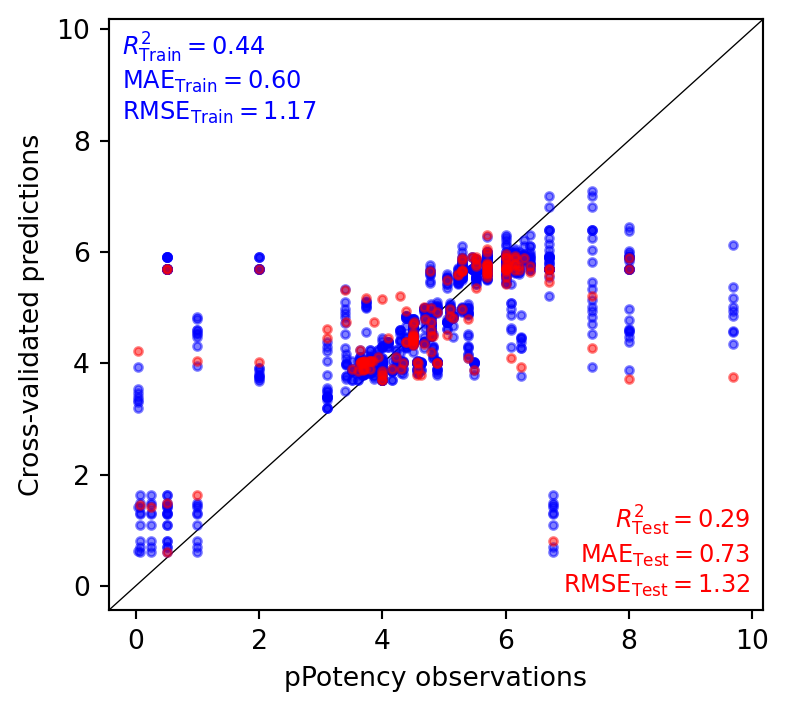

In [114]:
parity_plot(x=Y_obs_train, 
            y=Y_cv_pred_train, 
            x_test=Y_obs_test, 
            y_test=Y_cv_pred_test, 
            xlabel="pPotency observations", 
            ylabel="Cross-validated predictions",
            savetitle=resultsDir + 'YersiniaPestis/YersiniaPestis_CV_TrTs.svg',
            save_formats=['svg', 'png'])

Generate a model trained on the whole data set, to be used for prediction tasks

### Train/test split

Training samples: 122
Test samples: 31
Feature dimensions: 15

Running GridSearchCV with 1 parallel jobs...

------------------------------------------------------------
Best Hyperparameters:
------------------------------------------------------------
  C: 5
  epsilon: 0.1
  kernel: rbf

Best CV MAE (on training folds): 0.66

------------------------------------------------------------
PERFORMANCE COMPARISON:
------------------------------------------------------------
Metric     Training        Test            Difference     
------------------------------------------------------------
R²         0.52            0.06            0.45           
MAE        0.47            0.93            0.46           
RMSE       1.02            1.79            0.77           
------------------------------------------------------------


Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/YersiniaPestis/YersiniaPestis_fullData_TrTs.svg
Saved: /mnt/data.ese/nfs/users/sghos

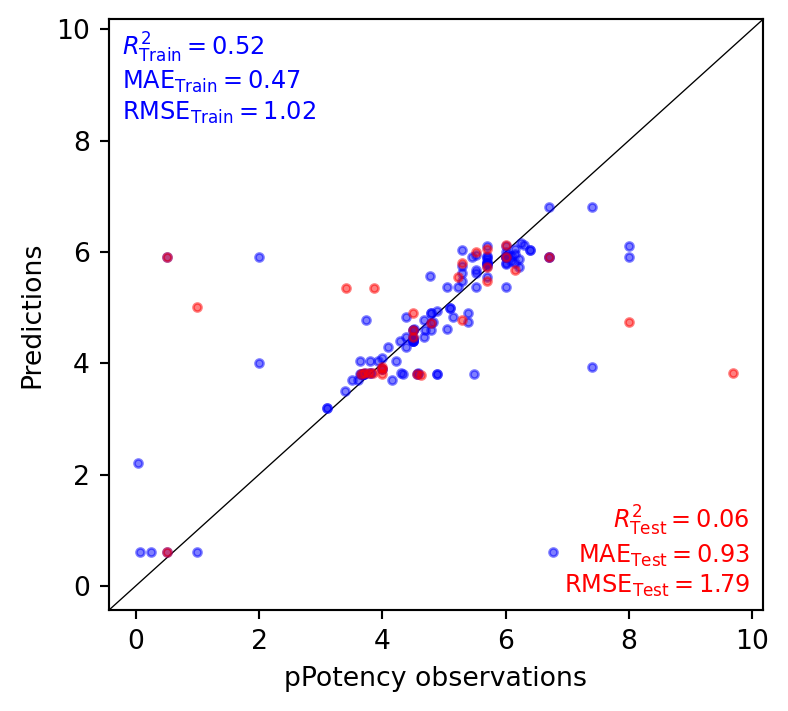

CPU times: user 2 s, sys: 56.3 ms, total: 2.05 s
Wall time: 2.05 s


In [116]:
%%time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

# ---------------------------
# 1. TRAIN-TEST SPLIT
# ---------------------------
# Since you're working with only one virus group, use regular train_test_split
X_train_smi, X_test_smi, Y_train, Y_test = train_test_split(
    smiles, Y, 
    test_size=0.2, 
    random_state=42,
    shuffle=True
)

print(f"Training samples: {len(X_train_smi)}")
print(f"Test samples: {len(X_test_smi)}")

# ---------------------------
# 2. FIT MACAW ON TRAINING DATA ONLY
# ---------------------------
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=100, 
    random_state=39
)
mcw.fit(X_train_smi, Y_train)

# Transform both train and test
X_train = mcw.transform(X_train_smi)
X_test = mcw.transform(X_test_smi)

print(f"Feature dimensions: {X_train.shape[1]}")

# ---------------------------
# 3. GRID SEARCH ON TRAINING DATA ONLY
# ---------------------------
n_jobs = 1

regr_pred = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid,
    cv=5,
    refit=True,
    n_jobs=n_jobs,
    verbose=0,
    scoring='neg_mean_absolute_error',
    return_train_score=True,
    pre_dispatch='2*n_jobs'
)

print(f"\nRunning GridSearchCV with {n_jobs} parallel jobs...")
regr_pred.fit(X_train, Y_train)

# ---------------------------
# 4. DISPLAY BEST HYPERPARAMETERS
# ---------------------------
print("\n" + "-"*60)
print("Best Hyperparameters:")
print("-"*60)
for param, value in regr_pred.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest CV MAE (on training folds): {-regr_pred.best_score_:.2f}")

# ---------------------------
# 5. PREDICTIONS AND METRICS
# ---------------------------
# Training predictions (in-sample)
y_train_pred = regr_pred.predict(X_train)

# Test predictions (held-out)
y_test_pred = regr_pred.predict(X_test)

# Calculate metrics for TRAIN
train_r2 = r2_score(Y_train, y_train_pred)
train_mae = mean_absolute_error(Y_train, y_train_pred)
train_rmse = np.sqrt(np.mean((Y_train - y_train_pred)**2))

# Calculate metrics for TEST
test_r2 = r2_score(Y_test, y_test_pred)
test_mae = mean_absolute_error(Y_test, y_test_pred)
test_rmse = np.sqrt(np.mean((Y_test - y_test_pred)**2))

# ---------------------------
# 6. DISPLAY RESULTS
# ---------------------------
print("\n" + "-"*60)
print("PERFORMANCE COMPARISON:")
print("-"*60)
print(f"{'Metric':<10} {'Training':<15} {'Test':<15} {'Difference':<15}")
print("-"*60)
print(f"{'R²':<10} {train_r2:<15.2f} {test_r2:<15.2f} {abs(train_r2-test_r2):<15.2f}")
print(f"{'MAE':<10} {train_mae:<15.2f} {test_mae:<15.2f} {abs(train_mae-test_mae):<15.2f}")
print(f"{'RMSE':<10} {train_rmse:<15.2f} {test_rmse:<15.2f} {abs(train_rmse-test_rmse):<15.2f}")
print("-"*60)

# Check for overfitting
overfit_gap = train_r2 - test_r2
if overfit_gap > 0.1:
    print("\n  WARNING: Possible overfitting detected (R² gap > 0.1)")
elif test_r2 >= 0.7:
    print("\n Good generalization performance!")

print("\n" + "="*60)

# ---------------------------
# 7. GENERATE PARITY PLOT
# ---------------------------
parity_plot(
    x=Y_train,                      # observed train
    y=y_train_pred,                 # predicted train (in-sample)
    x_test=Y_test,                  # observed test
    y_test=y_test_pred,             # predicted test (held-out)
    xlabel="pPotency observations",
    ylabel="Predictions",
    savetitle=resultsDir + 'YersiniaPestis/YersiniaPestis_fullData_TrTs.svg',
    save_formats=['svg', 'png']
)

## 2. Discovery of new hits specific to all Bacteriaes (data source Enamine_antiviralsData.csv)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models `regr` above, which use 15-D MACAW embeddings as their input. The custom library ("Enamine_antiviralsData.csv") compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

In [117]:
EnamineAntibacterialsData = pd.read_csv(dataDir + "Enamine/Enamine_Antibacterial_Library_plated_32000cmpds_20251019.csv",
                                    sep=",", comment=None, skipinitialspace=True, engine="python", encoding="utf-8",          
                                     skiprows=1, skip_blank_lines=True)
print(EnamineAntibacterialsData.shape)
smi_lib = EnamineAntibacterialsData.SMILES
print(f"Total compounds to screen: {len(smi_lib)}")
EnamineAntibacterialsData.head()

(32000, 11)
Total compounds to screen: 32000


,SMILES,Catalog ID,MW,MW (desalted),ClogP,logS,HBD,HBA,TPSA,RotBonds,AnalogsFromREAL
0,CC1=NN=C(COC(=O)C=2C=CC(=C(C2)[N+]([O-])=O)N3C...,Z19065527,374.392,374.392,2.754,-4.286,0,6,111.600,6,https://real.enamine.net/public-enum-files/Z19...
1,CC1=NC2=NC(=NN2C(C)=C1C)SCCCOC(=O)NC(N)=O,Z1203040657,338.387,338.387,1.246,-4.006,2,5,124.500,8,https://real.enamine.net/public-enum-files/Z12...
2,CC=1C=CC(=CC1)S(=O)(=O)NCC(=O)OCC(=O)N2CC(C)OC...,Z19154552,384.449,384.449,2.021,-3.375,1,5,102.010,6,https://real.enamine.net/public-enum-files/Z19...
3,CC(C)N1C=NC(=C1)S(=O)(=O)NC=2C=CN(CC=3C=CC=CN3)N2,Z1509821346,346.409,346.409,1.094,-1.970,1,5,94.700,6,https://real.enamine.net/public-enum-files/Z15...
4,O=C(O)CC=1C=CC(=CC1)S(=O)(=O)NC=2C=CC(Cl)=CC2O,Z1509833014,341.768,341.768,2.254,-3.235,3,5,103.700,4,https://real.enamine.net/public-enum-files/Z15...


Load pre-trained models

Generate MACAW embeddings

In [118]:
print("\nComputing MACAW embeddings")
X1_lib = mcw.transform(smi_lib)
print(f"Embedding shape: {X1_lib.shape}")


Computing MACAW embeddings
Embedding shape: (32000, 15)


Predict pPotency

In [119]:
print("Generating predictions")
Y1_lib_pred = regr_pred.predict(X1_lib)
print(f"Predictions shape: {Y1_lib_pred.shape}")

Generating predictions
Predictions shape: (32000,)


Add predictions to dataframe

In [120]:
EnamineAntibacterialsData_predicted = EnamineAntibacterialsData.copy()
EnamineAntibacterialsData_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
EnamineAntibacterialsData_predicted['IC50 (M)'] = 10 ** (-EnamineAntibacterialsData_predicted['pPotency_prediction'])

EnamineAntibacterialsData_predicted = EnamineAntibacterialsData_predicted.filter(
    items=["SMILES", "pPotency_prediction", "IC50 (M)"]
)
EnamineAntibacterialsData_predicted

,SMILES,pPotency_prediction,IC50 (M)
0,CC1=NN=C(COC(=O)C=2C=CC(=C(C2)[N+]([O-])=O)N3C...,4.683,2.074e-05
1,CC1=NC2=NC(=NN2C(C)=C1C)SCCCOC(=O)NC(N)=O,4.536,2.908e-05
2,CC=1C=CC(=CC1)S(=O)(=O)NCC(=O)OCC(=O)N2CC(C)OC...,4.739,1.823e-05
3,CC(C)N1C=NC(=C1)S(=O)(=O)NC=2C=CN(CC=3C=CC=CN3)N2,5.054,8.827e-06
4,O=C(O)CC=1C=CC(=CC1)S(=O)(=O)NC=2C=CC(Cl)=CC2O,5.020,9.555e-06
...,...,...,...
31995,CCOCCCOC(=O)C1=CC(=C(C)S1)[N+]([O-])=O,4.691,2.038e-05
31996,CC(C)C(NS(=O)(=O)CC12CCC(CC1=O)C2(C)C)C(N)=O,5.243,5.711e-06
31997,CNC(=O)CN1CCC(CC1)NS(=O)(=O)CCCC(F)(F)F,4.814,1.534e-05
31998,CCOC(=O)NC1CCCN(C1)C(=O)C2=CC(=NN2C3CC3)C(F)(F)F,4.258,5.521e-05


Let us represent the predictions of both models:

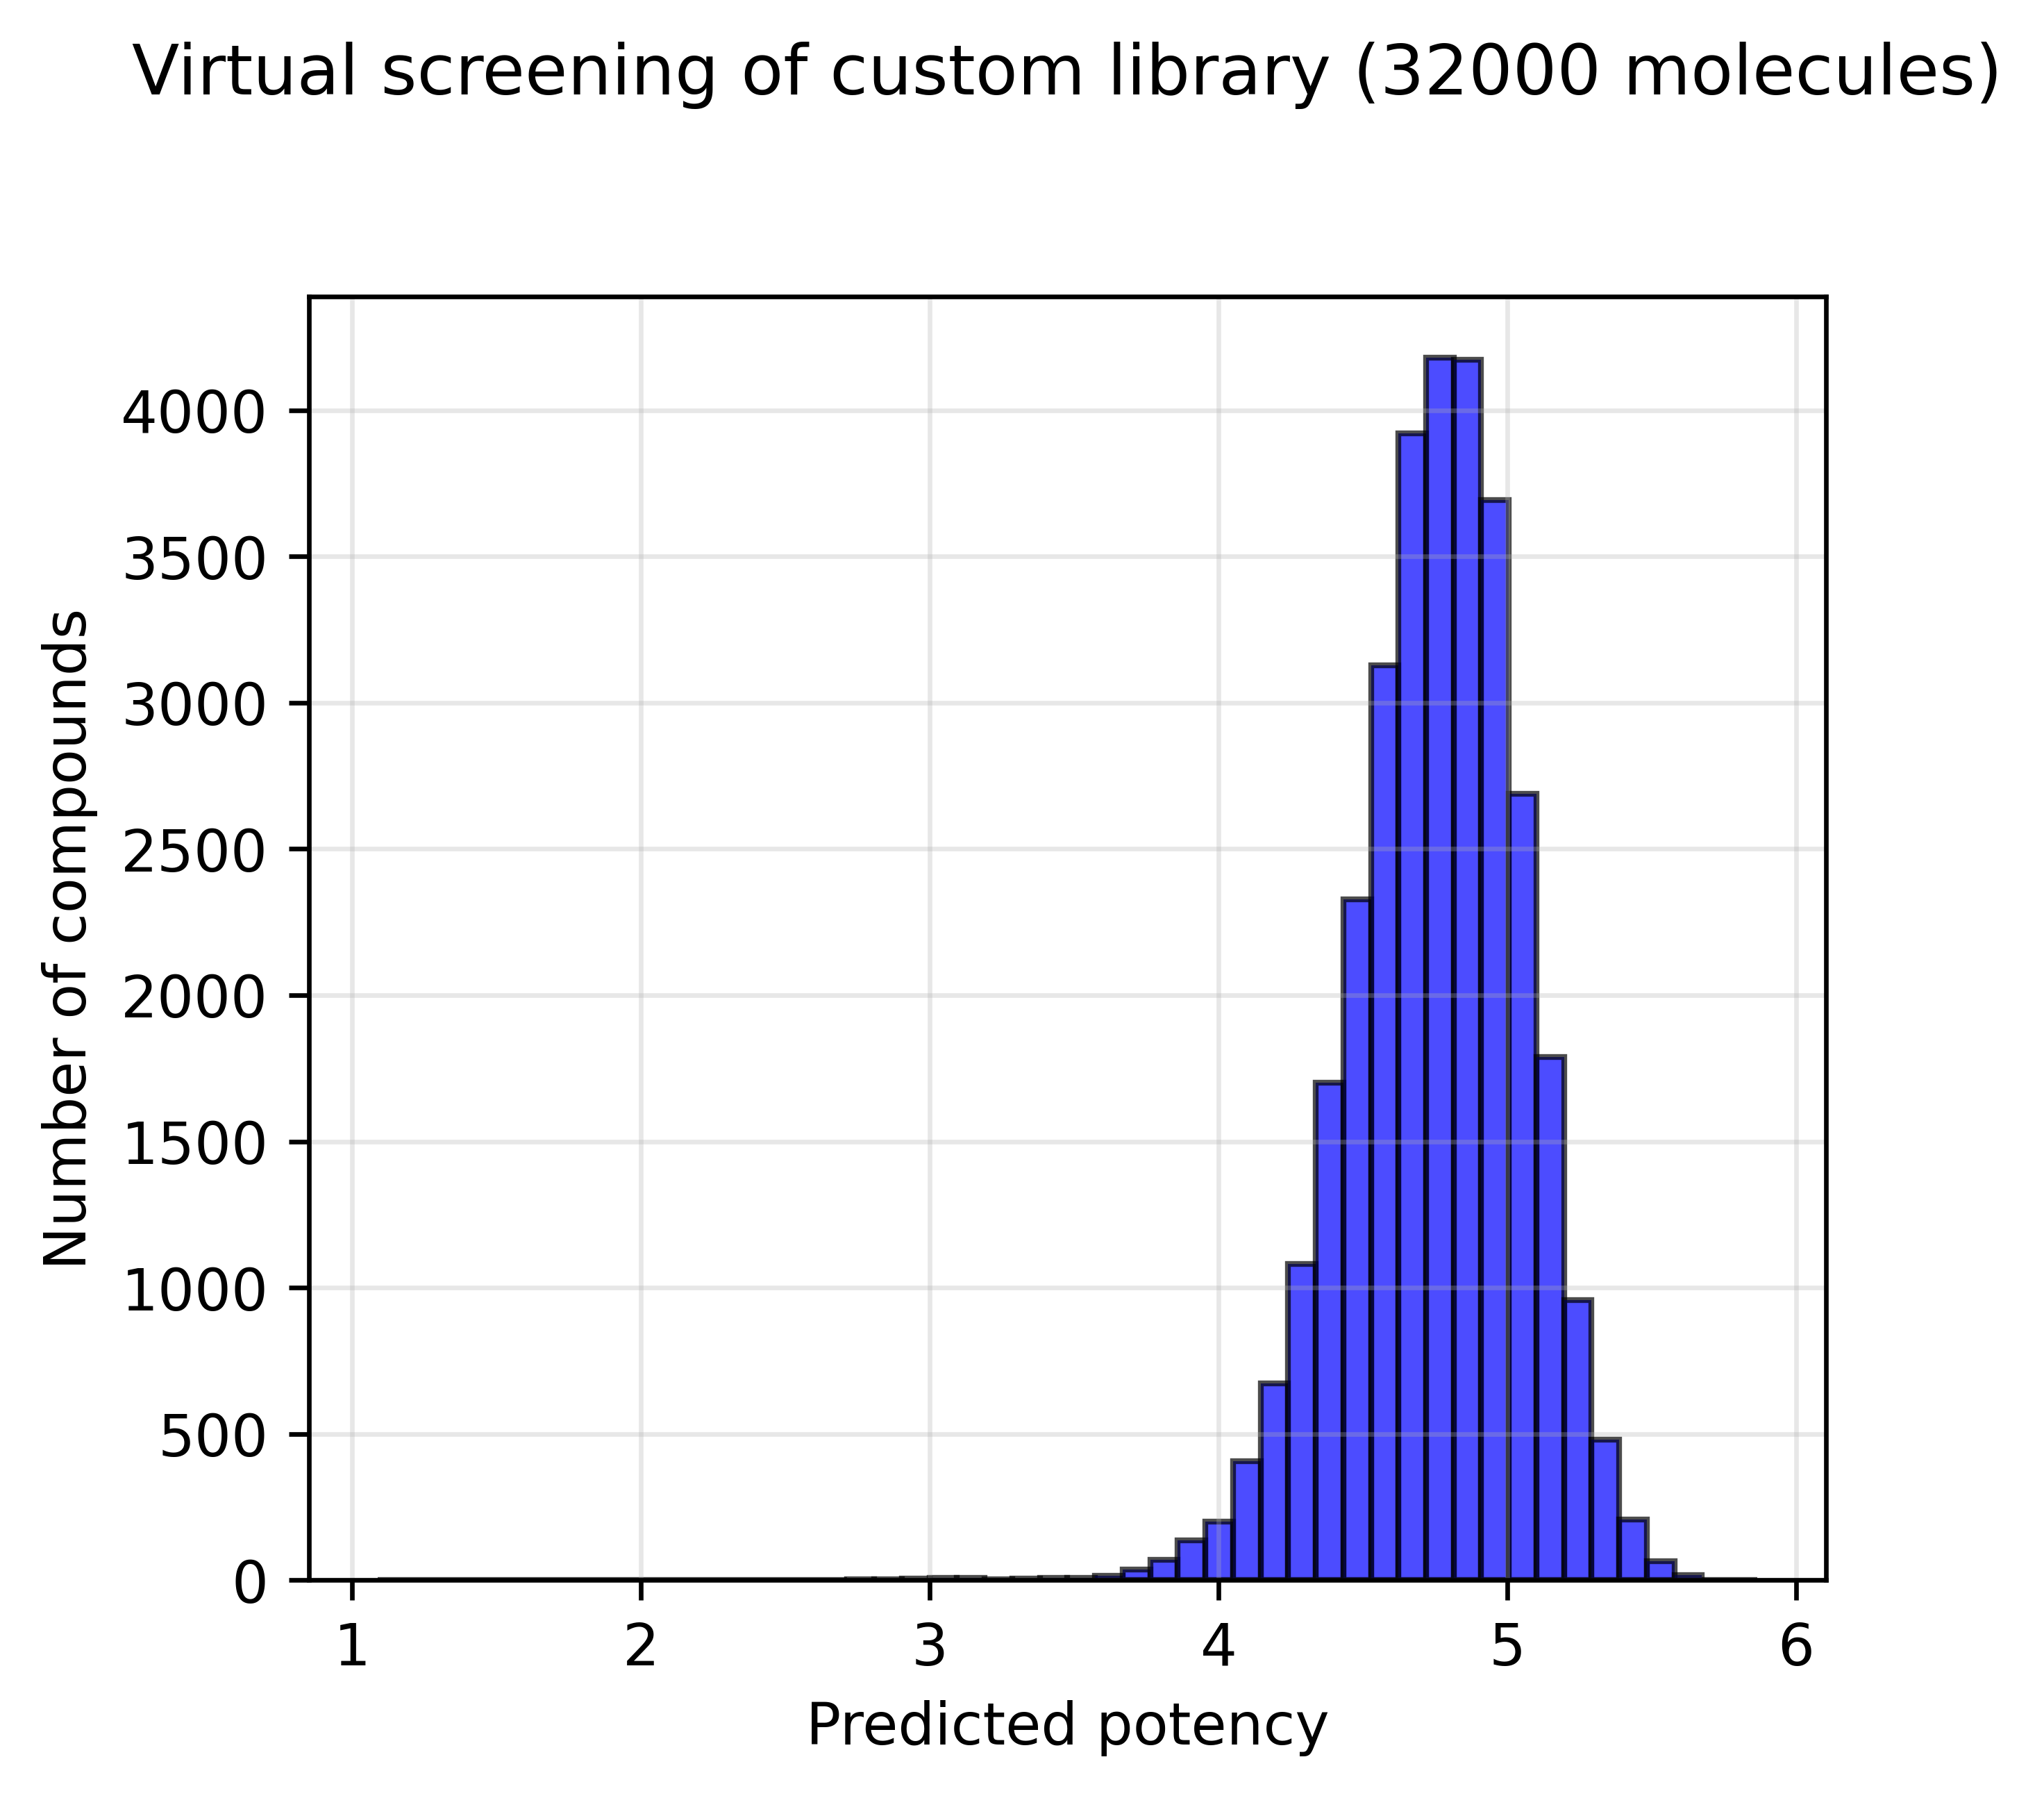

In [121]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
plt.title(f"Virtual screening of custom library ({len(smi_lib)} molecules)", pad=35)
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2, label='pPotency = 5.0 (minimum)') 
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2, label='pPotency = 6.0 (good)')
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2, label='pPotency = 7.0 (excellent)')

# Legend on top, outside plot area
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(resultsDir + 'YersiniaPestis/YersiniaPestis_validation.svg', bbox_inches='tight', dpi=300)
plt.savefig(resultsDir + 'YersiniaPestis/YersiniaPestis_validation.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [122]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

High priority (pPotency ≥ 7.0): 0 compounds
Medium priority (6 ≤ pPotency < 7.0): 0 compounds
Low priority (5 ≤ pPotency < 6): 6380 compounds


In [123]:
EnamineAntibacterialsData_final = EnamineAntibacterialsData.iloc[idx].copy()
EnamineAntibacterialsData_final['pPotency_prediction'] = Y1_lib_pred[idx]

EnamineAntibacterialsData_final

,SMILES,Catalog ID,MW,MW (desalted),ClogP,logS,HBD,HBA,TPSA,RotBonds,AnalogsFromREAL,pPotency_prediction


In [ ]:
molecules = [Chem.MolFromSmiles(smi) for smi in EnamineAntibacterialsData_final.SMILES[:50]]

Draw.MolsToGridImage(molecules, subImgSize=(200,200), molsPerRow=3, useSVG=True)

### Top 20 compounds with higher pPotency

In [125]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

Top 20 compounds cutoff pPotency: 5.58
Highest predicted pPotency: 5.86
Range of top 20: 5.58 - 5.86


In [126]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
EnamineAntibacterialsData_top20 = EnamineAntibacterialsData.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
EnamineAntibacterialsData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
EnamineAntibacterialsData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
EnamineAntibacterialsData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("\n Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
EnamineAntibacterialsData_top20 = EnamineAntibacterialsData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "IC50 (M)"]
)
EnamineAntibacterialsData_top20

----------------------------------------------------------------------
Top 20 Compounds with Highest Predicted pPotency
----------------------------------------------------------------------

Cutoff Values (20th ranked compound):
  pPotency:    5.578
  IC50:        2.644e-06 M  (2643.92 nM)

Best Values (1st ranked compound):
  pPotency:    5.865
  IC50:        1.365e-06 M  (1365.02 nM)

 Range for Top 20 Compounds:
pPotency Range:  5.578 - 5.865

IC50 Range (M):  2.644e-06 - 1.365e-06


,Rank,SMILES,pPotency_prediction,IC50 (M)
11822,1,CC1(C)S[C@@H]2[C@H](NC(=O)[C@H](N)C=3C=CC(O)=C...,5.865,1.365e-06
21943,2,CC(NS(=O)(=O)C1=CC=CS1)C(=O)NC(C=2C=CC=CC2)C(C...,5.758,1.746e-06
9395,3,COC(=O)NC=1C=CC(=CC1)NC(=O)C2C(C(=O)O)C3C=CC2C3,5.668,2.147e-06
15807,4,CC(C)[C@@H](NS(=O)(=O)C1=CN=C(S1)C=2C=CC=CC2)C...,5.666,2.157e-06
24961,5,CC(=O)N[C@@H]1[C@@H](O)[C@H](O)[C@@H](CO)O[C@H...,5.664,2.169e-06
22033,6,CC1(C)CNC(=O)C1NS(=O)(=O)CC=2C=CC(C#N)=CC2,5.645,2.262e-06
12057,7,CC(NS(C)(=O)=O)C(=O)NC1C=2C=CC=CC2CC1C,5.639,2.297e-06
29707,8,CC(C)NC(=O)OC1CN(C1)C(=O)C=2C=C(NN2)C3=CC=CO3,5.636,2.310e-06
15145,9,CCNC(=O)C(C)NC(=O)C(NS(=O)(=O)C1=CC=CS1)C(C)C,5.623,2.380e-06
18471,10,CCOC(=O)NC(C(=O)OC(C)C=1C=CC=C(C1)N2C=NN=N2)C(C)C,5.616,2.419e-06


 Saved PNG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/YersiniaPestis/YersiniaPestis_predictedCompounds.png
 Saved SVG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/YersiniaPestis/YersiniaPestis_predictedCompounds.svg


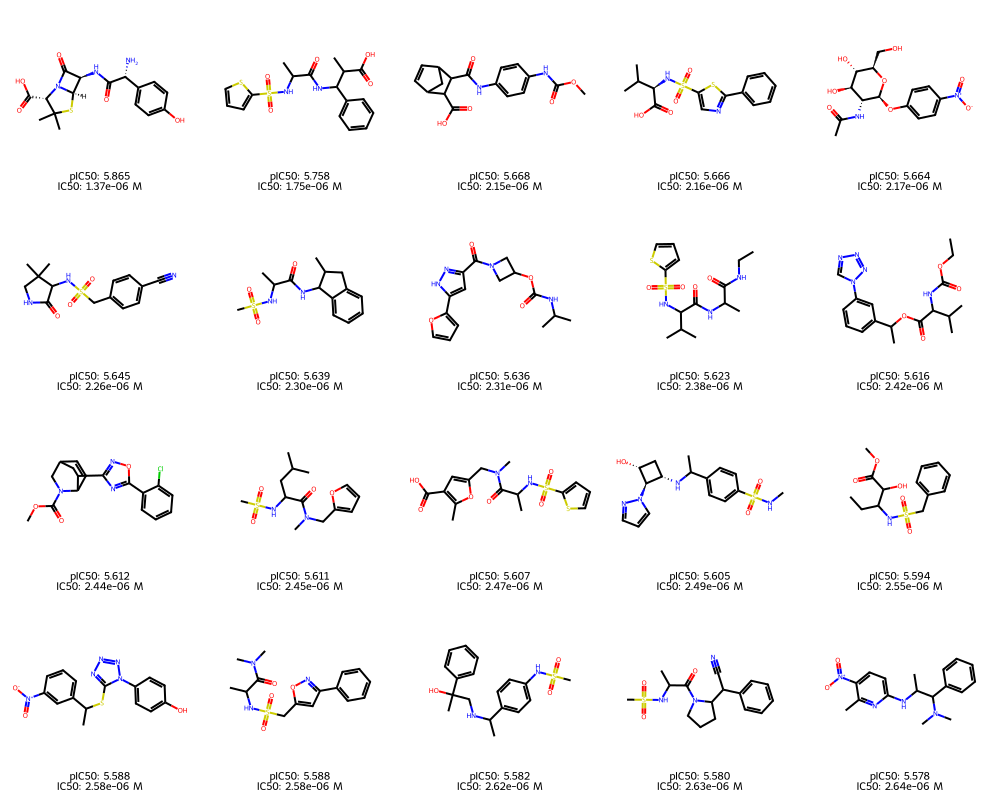

In [127]:
from rdkit import Chem
from rdkit.Chem import Draw
import os
from PIL import Image

# Setup paths
output_dir = resultsDir + 'YersiniaPestis/'
os.makedirs(output_dir, exist_ok=True)

# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in EnamineAntibacterialsData_top20.SMILES[:50]]

# Create legends
legends = []
for idx, row in EnamineAntibacterialsData_top20[:50].iterrows():
    legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = output_dir + 'YersiniaPestis_predictedCompounds.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = output_dir + 'YersiniaPestis_predictedCompounds.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)  

### 2.2 Discovery of new hits specific to Staphylococcus (data source Life chemicals data set)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models regr above, which use 15-D MACAW embeddings as their input. The custom library compiled from commercial catalogs by Life chemicals. In particular, we are interested in molecules with high predicted pPotency.

In [128]:
# Read all molecules from SDF
supplier = Chem.SDMolSupplier(dataDir + "LifeChemicals/LC_Antibacterial_Focused_Library.sdf")
mols = [mol for mol in supplier if mol is not None]

# Extract properties into DataFrame
records = []
for mol in mols:
    props = mol.GetPropsAsDict()
    props["SMILES"] = Chem.MolToSmiles(mol)
    records.append(props)

LCAntibacterialsData = pd.DataFrame(records)

print(f"\nOriginal shape: {LCAntibacterialsData.shape}")

# Show duplicate SMILES if any
duplicates = LCAntibacterialsData[LCAntibacterialsData.duplicated(subset='SMILES', keep=False)]
if len(duplicates) > 0:
    print(f"\nFound {duplicates['SMILES'].nunique()} SMILES that appear multiple times:")
    print(duplicates.groupby('SMILES').size().sort_values(ascending=False).head(10))

# Remove duplicates (keep first occurrence)
LCAntibacterialsData = LCAntibacterialsData.drop_duplicates(subset='SMILES', keep='first')

print(f"\nAfter removing duplicates: {LCAntibacterialsData.shape}")
smi_lib = LCAntibacterialsData.SMILES
print(f"Total compounds to screen: {len(smi_lib)}")
LCAntibacterialsData.head()


Original shape: (15538, 26)

Found 3 SMILES that appear multiple times:
SMILES
CC(N)C(=O)O         2
CNC(CO)Cc1ccccc1    2
CNCC(O)c1ccccc1     2
dtype: int64

After removing duplicates: (15535, 26)
Total compounds to screen: 15535


,IDNUMBER,Chemical_Name,CAS,PriceCoeff,MW,Description,FSP3,clogP,TPSA,H-acceptors,...,Reference_ID,Activity_type,Activity_value_,Activity_units_,Activity_comment,Target_name,Target_organism,Target_type,SMILES,PPDS
0,F6540-4248,"6-(3-methoxypiperidin-1-yl)-N,N-dimethylpyrimi...",2097927-68-7,1.500,236.310,oil,0.670,1.600,41.490,3,...,CHEMBL4548594,Inhibition,37.210,%,Average; N=1,Pseudomonas aeruginosa,Pseudomonas aeruginosa,ORGANISM,COC1CCCN(c2cc(N(C)C)ncn2)C1,NaN
1,F6541-0830,"1-(5,6,7,8-tetrahydroquinazolin-4-yl)piperidin...",1541766-76-0,1.500,233.310,oil,0.690,1.510,49.250,3,...,CHEMBL4533334,Inhibition,26.560,%,Average; N=1,Pseudomonas aeruginosa,Pseudomonas aeruginosa,ORGANISM,OC1CCCN(c2ncnc3c2CCCC3)C1,NaN
2,F6541-5261,5-fluoro-2-[4-(propan-2-yl)piperazin-1-yl]pyri...,2034458-11-0,1.500,224.280,oil,0.640,1.460,32.260,3,...,CHEMBL4542429,Inhibition,25.160,%,Average; N=1,Pseudomonas aeruginosa,Pseudomonas aeruginosa,ORGANISM,CC(C)N1CCN(c2ncc(F)cn2)CC1,NaN
3,F6543-7286,"6-(2,6-dimethylmorpholin-4-yl)-N,N-dimethylpyr...",2034461-31-7,1.500,236.310,solid,0.670,1.830,41.490,3,...,CHEMBL4548594,Inhibition,37.210,%,Average; N=1,Pseudomonas aeruginosa,Pseudomonas aeruginosa,ORGANISM,CC1CN(c2cc(N(C)C)ncn2)CC(C)O1,NaN
4,F6570-1027,1-[6-(dimethylamino)pyrimidin-4-yl]piperidin-3-ol,1903487-65-9,1.500,222.280,solid,0.640,0.840,52.490,3,...,CHEMBL4548594,Inhibition,37.210,%,Average; N=1,Pseudomonas aeruginosa,Pseudomonas aeruginosa,ORGANISM,CN(C)c1cc(N2CCCC(O)C2)ncn1,NaN


In [129]:
print("\nComputing MACAW embeddings")
X1_lib = mcw.transform(smi_lib)
print(f"Embedding shape: {X1_lib.shape}")


Computing MACAW embeddings
Embedding shape: (15535, 15)


In [130]:
print("Generating predictions")
Y1_lib_pred = regr_pred.predict(X1_lib)
print(f"Predictions shape: {Y1_lib_pred.shape}")

Generating predictions
Predictions shape: (15535,)


In [131]:
LCAntibacterialsData_predicted = LCAntibacterialsData.copy()
LCAntibacterialsData_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
LCAntibacterialsData_predicted['IC50 (M)'] = 10 ** (-LCAntibacterialsData_predicted['pPotency_prediction'])

LCAntibacterialsData_predicted = LCAntibacterialsData_predicted.filter(
    items=["SMILES", "pPotency_prediction", "IC50 (M)"]
)
LCAntibacterialsData_predicted

,SMILES,pPotency_prediction,IC50 (M)
0,COC1CCCN(c2cc(N(C)C)ncn2)C1,5.075,8.410e-06
1,OC1CCCN(c2ncnc3c2CCCC3)C1,4.662,2.177e-05
2,CC(C)N1CCN(c2ncc(F)cn2)CC1,4.841,1.443e-05
3,CC1CN(c2cc(N(C)C)ncn2)CC(C)O1,5.268,5.390e-06
4,CN(C)c1cc(N2CCCC(O)C2)ncn1,4.995,1.012e-05
...,...,...,...
15533,O=C1c2cccc3cccc(c23)C(=O)N1CCCN(C(=O)c1ccc(-c2...,4.062,8.679e-05
15534,O=C1Nc2ccc(S(=O)(=O)Nc3ccc(NS(=O)(=O)c4ccc5c6c...,4.384,4.127e-05
15535,Cc1ncc(CO)c2cc(C(=O)Nc3cccc4ccccc34)/c(=N/c3cc...,5.034,9.240e-06
15536,CCOC(=O)c1sc(NC(=O)c2ccc(Oc3ccc(C(=O)Nc4nc(-c5...,4.224,5.973e-05


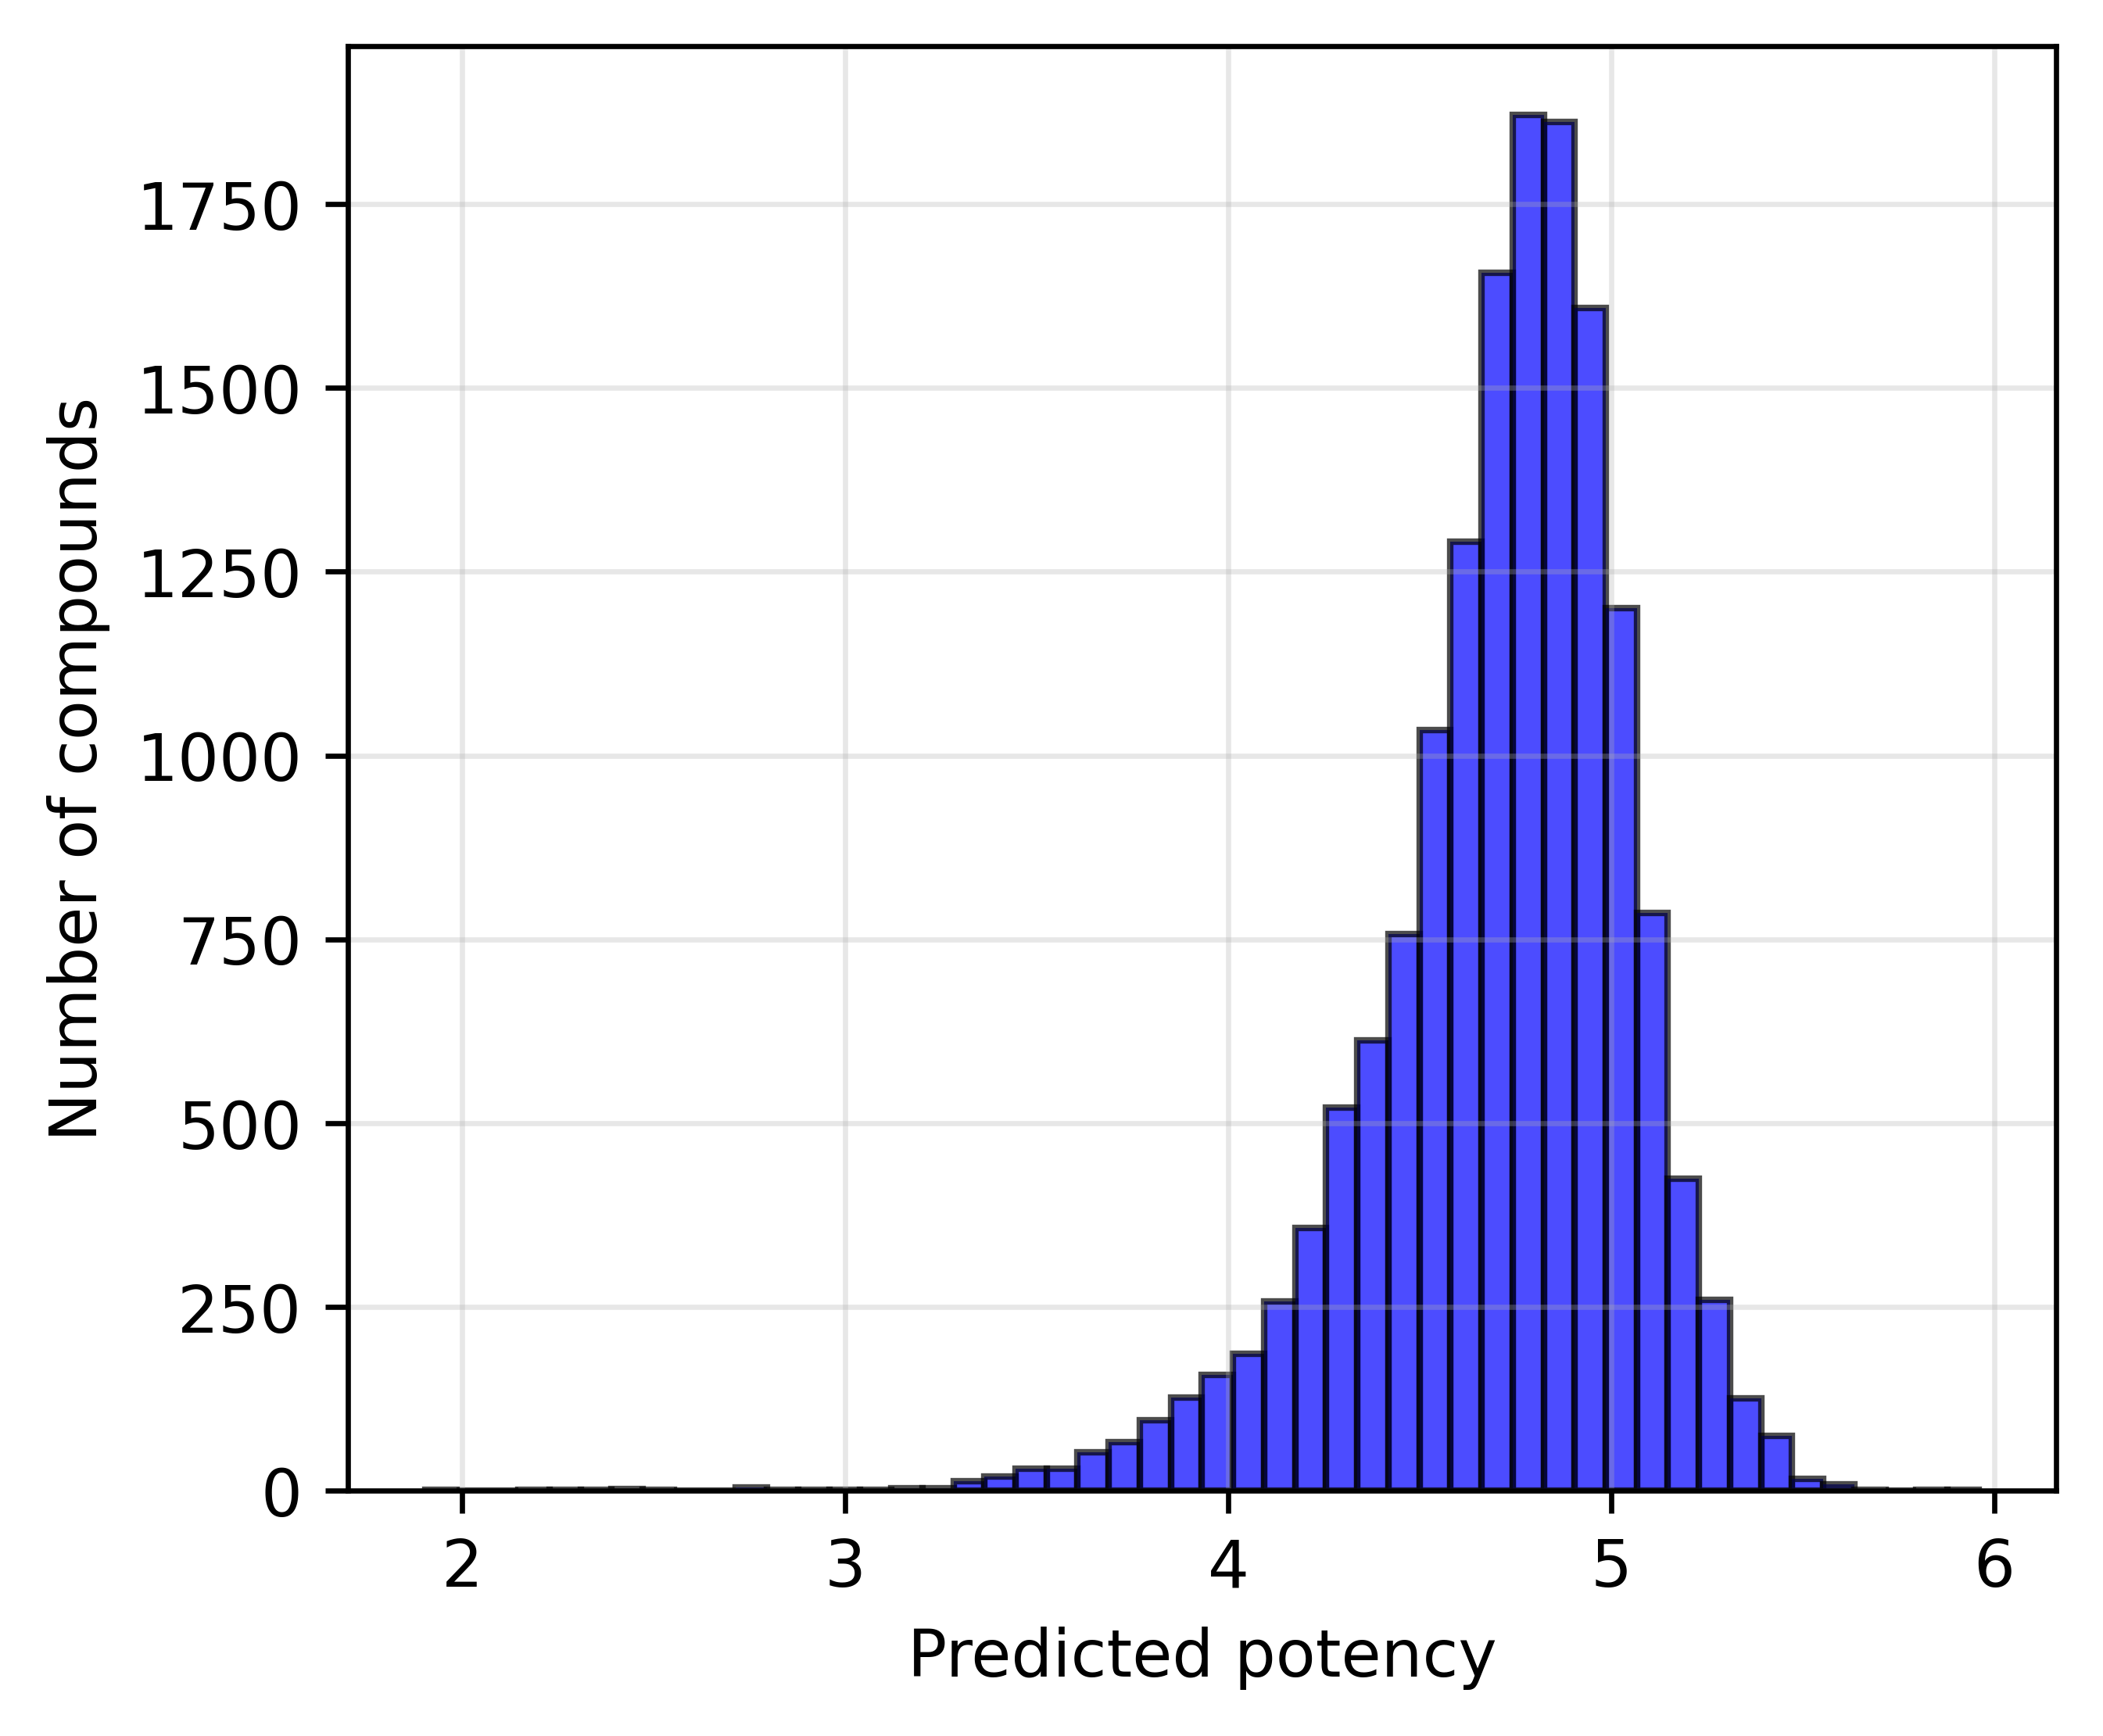

In [132]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.title(f"Virtual screening of custom library ({len(smi_lib)} molecules)", pad=35)
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2) # label='pPotency = 5.0 (minimum)'
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2) # label='pPotency = 6.0 (good)'
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2) # label='pPotency = 7.0 (excellent)'

# Legend on top, outside plot area
#plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(resultsDir + 'YersiniaPestis/YersiniaPestis_validationLCDatasets.svg', bbox_inches='tight', dpi=300)
plt.savefig(resultsDir + 'YersiniaPestis/YersiniaPestis_validationLCDatasets.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [133]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

High priority (pPotency ≥ 7.0): 0 compounds
Medium priority (6 ≤ pPotency < 7.0): 0 compounds
Low priority (5 ≤ pPotency < 6): 2646 compounds


In [134]:
LCAntibacterialsData_final = LCAntibacterialsData.iloc[idx].copy()
LCAntibacterialsData_final['pPotency_prediction'] = Y1_lib_pred[idx]
LCAntibacterialsData_final = LCAntibacterialsData_final.filter(
    items=["SMILES", "pPotency_prediction", "clogP"]
)
LCAntibacterialsData_final

,SMILES,pPotency_prediction,clogP


In [ ]:
molecules = [Chem.MolFromSmiles(smi) for smi in LCAntibacterialsData_final.SMILES[:50]]

Draw.MolsToGridImage(molecules, subImgSize=(200,200), molsPerRow=3, useSVG=True)

### Top 20 compounds with higher pPPotency

In [136]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

Top 20 compounds cutoff pPotency: 5.49
Highest predicted pPotency: 5.96
Range of top 20: 5.49 - 5.96


In [137]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
LCAntibacterialsData_top20 = LCAntibacterialsData.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
LCAntibacterialsData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
LCAntibacterialsData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
LCAntibacterialsData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*50)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*50)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
LCAntibacterialsData_top20 = LCAntibacterialsData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "IC50 (M)"]
)
LCAntibacterialsData_top20

--------------------------------------------------
Top 20 Compounds with Highest Predicted pPotency
--------------------------------------------------

Cutoff Values (20th ranked compound):
  pPotency:    5.489
  IC50:        3.240e-06 M  (3239.98 nM)

Best Values (1st ranked compound):
  pPotency:    5.959
  IC50:        1.099e-06 M  (1099.09 nM)
Range for Top 20 Compounds:
pPotency Range:  5.489 - 5.959

IC50 Range (M):  3.240e-06 - 1.099e-06


,Rank,SMILES,pPotency_prediction,IC50 (M)
15414,1,Cc1ccc(C2=NN(C(=S)Nc3ccccc3)C(c3cccc([N+](=O)[...,5.959,1.099e-06
4081,2,CC1(C)SC2C(NC(=O)Cc3ccccc3)C(=O)N2C1C(=O)[O-]....,5.807,1.561e-06
9075,3,C/C=C/c1ccc(OC2OC(CO)C(O)C(O)C2NC(C)=O)c(OC)c1,5.695,2.020e-06
12318,4,CC(C)C(C(=O)O)N1C(=O)/C(=C/c2ccccc2[N+](=O)[O-...,5.614,2.432e-06
12153,5,CC(=O)Nc1ccc(N2C(=O)/C(=C/c3cccc(O)c3)SC2=S)cc1,5.610,2.457e-06
11797,6,CNC(=S)N1N=C(c2ccccc2)CC1c1cccc([N+](=O)[O-])c1,5.606,2.477e-06
8974,7,CC(C)C(C(=O)O)N1C(=O)/C(=C/c2cccc(Br)c2)SC1=S,5.593,2.550e-06
627,8,CC(C)(C)C(NC(=O)OCc1ccccc1)C(=O)O,5.586,2.592e-06
8599,9,CC(C)C(C(=O)O)N1C(=O)/C(=C/c2ccccc2Cl)SC1=S,5.576,2.654e-06
7211,10,CC(C)C(C(=O)O)N1C(=O)/C(=C/c2ccccn2)SC1=S,5.574,2.666e-06


 Saved PNG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/YersiniaPestis/YersiniaPestis_predictedCompounds_LCDataset.png
 Saved SVG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/YersiniaPestis/YersiniaPestis_predictedCompounds_LCDataset.svg


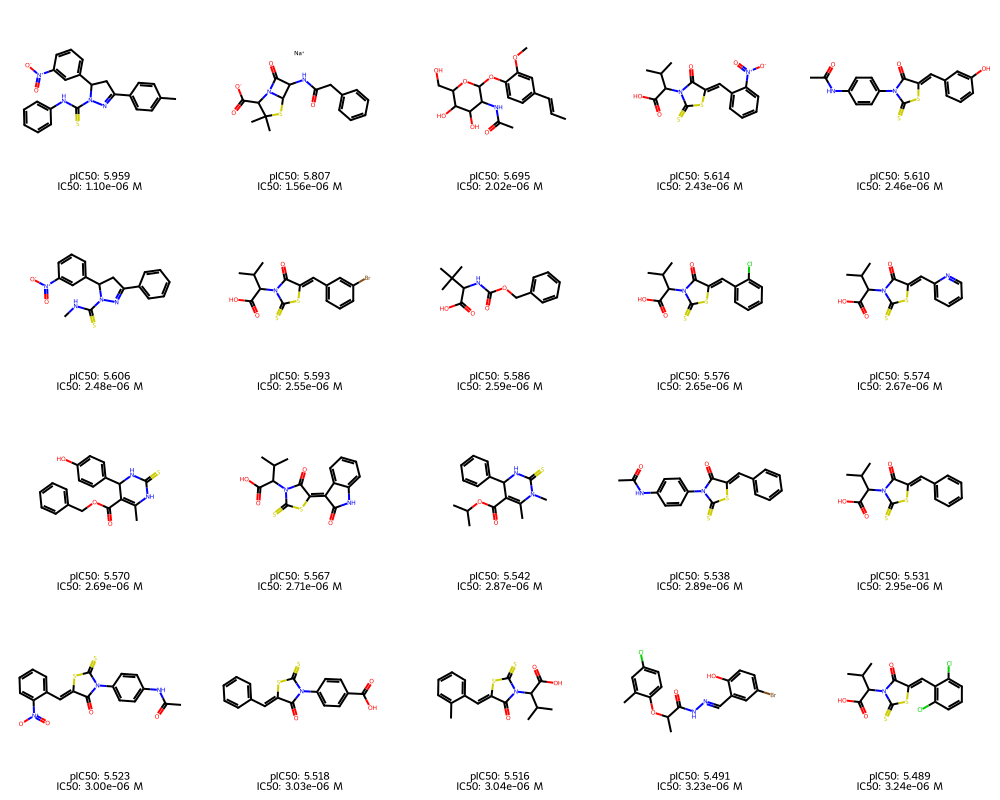

In [138]:
from rdkit import Chem
from rdkit.Chem import Draw
import os
from PIL import Image

# Setup paths
output_dir = resultsDir + 'YersiniaPestis/'
os.makedirs(output_dir, exist_ok=True)

# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in LCAntibacterialsData_top20.SMILES[:50]]

# Create legends
legends = []
for idx, row in LCAntibacterialsData_top20[:50].iterrows():
    legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = output_dir + 'YersiniaPestis_predictedCompounds_LCDataset.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = output_dir + 'YersiniaPestis_predictedCompounds_LCDataset.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img) 

### 2.3 Discovery of new hits specific to all viruses (data source ChemDiv antibiotics)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models regr above, which use 15-D MACAW embeddings as their input. The custom library ("ChemDiv") compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

In [139]:
from rdkit import Chem


# Read all molecules from SDF
supplier = Chem.SDMolSupplier(dataDir + "ChemDiv/ChemDiv_Antibacterial_gramm_negative_12510.sdf")
mols = [mol for mol in supplier if mol is not None]

# Extract properties into DataFrame
records = []
for mol in mols:
    props = mol.GetPropsAsDict()
    props["SMILES"] = Chem.MolToSmiles(mol)
    records.append(props)

ChemDivAntiBioticData = pd.DataFrame(records)

#ChemDivAntiBioticData = ChemDivAntiBioticData.rename(columns={
#    "SMILE": "SMILES",
#})

ChemDivAntiBioticData

,IDNUMBER,STEREO_COMMENTS,SMILE,LOGP,LOGD,LOGSW,N_ROTB,N_CHIRALS,H_ACCEPTORS,H_DONORS,PSA,WEIGHT_AVAILABLE1,CHEMNAME,SMILES,SALTDATA,SALTDATA_MOLWEIGHT
0,000L-0380,ACHIRAL,[O-][N+](c(cc1)ccc1C(Oc(cc1)ccc1-c1ccccc1)=O)=O,4.934,4.934,-5.149,5.000,0.000e+00,7.000,0.000e+00,53.726,34,"[1,1'-biphenyl]-4-yl 4-nitrobenzoate",O=C(Oc1ccc(-c2ccccc2)cc1)c1ccc([N+](=O)[O-])cc1,NaN,NaN
1,0071-0020,ACHIRAL,Cn(cc1)nc1C(N/N=C/c(cc1)ccc1OC)=O,1.256,1.255,-1.843,5.000,0.000e+00,5.000,1.000,57.790,12,N'-[(4-methoxyphenyl)methylidene]-1-methyl-1H-...,COc1ccc(/C=N/NC(=O)c2ccn(C)n2)cc1,NaN,NaN
2,0080-0039,RACEMIC MIXTURE,CC1(C)OC1COC(c(cc(cco1)c1c1)c1O1)=CC1=O,2.481,2.481,-3.143,3.000,1.000,6.000,0.000e+00,44.076,113,"5-[(3,3-dimethyloxiran-2-yl)methoxy]-7H-furo[3...",CC1(C)OC1COc1cc(=O)oc2cc3occc3cc12,NaN,NaN
3,0083-0046,ACHIRAL,O=C(Cc1ccccc1)c(cc1)ccc1-c1ccccc1,4.779,4.779,-5.194,4.000,0.000e+00,2.000,0.000e+00,12.942,985,"1-([1,1'-biphenyl]-4-yl)-2-phenylethan-1-one",O=C(Cc1ccccc1)c1ccc(-c2ccccc2)cc1,NaN,NaN
4,0089-0027,ACHIRAL,O=C(c1cccc(C(Nc(cc2)ccc2Oc2ccccc2)=O)c1)Nc(cc1...,7.293,7.292,-6.294,10.000,0.000e+00,6.000,2.000,59.916,4,"N~1~,N~3~-bis(4-phenoxyphenyl)benzene-1,3-dica...",O=C(Nc1ccc(Oc2ccccc2)cc1)c1cccc(C(=O)Nc2ccc(Oc...,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12505,Z601-8334,ACHIRAL,Nc1nc(Nc(cccc2)c2F)nc2ccccc12,3.415,3.097,-3.641,2.000,0.000e+00,2.000,3.000,48.570,460,"N~2~-(2-fluorophenyl)quinazoline-2,4-diamine",Nc1nc(Nc2ccccc2F)nc2ccccc12,HCl,36.461
12506,Z601-8612,ACHIRAL,CNc1nc(Nc(cccc2)c2F)nc2ccccc12,4.019,3.229,-4.160,3.000,0.000e+00,2.000,2.000,39.170,841,N~2~-(2-fluorophenyl)-N~4~-methylquinazoline-2...,CNc1nc(Nc2ccccc2F)nc2ccccc12,HCl,36.461
12507,Z601-8674,ACHIRAL,Nc1nc(Nc(cccc2)c2Cl)nc2ccccc12,3.686,3.268,-3.905,2.000,0.000e+00,2.000,3.000,48.570,336,"N~2~-(2-chlorophenyl)quinazoline-2,4-diamine",Nc1nc(Nc2ccccc2Cl)nc2ccccc12,NaN,NaN
12508,Z601-9100,ACHIRAL,CNc1nc(Nc(cccc2)c2Cl)nc2ccccc12,4.290,3.350,-4.279,3.000,0.000e+00,2.000,2.000,39.170,558,N~2~-(2-chlorophenyl)-N~4~-methylquinazoline-2...,CNc1nc(Nc2ccccc2Cl)nc2ccccc12,HCl,36.461


In [140]:
print(f"\nOriginal shape: {ChemDivAntiBioticData.shape}")

# Show duplicate SMILES if any
duplicates = ChemDivAntiBioticData[ChemDivAntiBioticData.duplicated(subset='SMILES', keep=False)]
if len(duplicates) > 0:
    print(f"\nFound {duplicates['SMILES'].nunique()} SMILES that appear multiple times:")
    print(duplicates.groupby('SMILES').size().sort_values(ascending=False).head(10))

# Remove duplicates (keep first occurrence)
ChemDivAntiBioticData = ChemDivAntiBioticData.drop_duplicates(subset='SMILES', keep='first')

print(f"\nAfter removing duplicates: {ChemDivAntiBioticData.shape}")
smi_lib = ChemDivAntiBioticData.SMILES
print(f"Total compounds to screen: {len(smi_lib)}")
ChemDivAntiBioticData.head()


Original shape: (12510, 16)

After removing duplicates: (12510, 16)
Total compounds to screen: 12510


,IDNUMBER,STEREO_COMMENTS,SMILE,LOGP,LOGD,LOGSW,N_ROTB,N_CHIRALS,H_ACCEPTORS,H_DONORS,PSA,WEIGHT_AVAILABLE1,CHEMNAME,SMILES,SALTDATA,SALTDATA_MOLWEIGHT
0,000L-0380,ACHIRAL,[O-][N+](c(cc1)ccc1C(Oc(cc1)ccc1-c1ccccc1)=O)=O,4.934,4.934,-5.149,5.000,0.000e+00,7.000,0.000e+00,53.726,34,"[1,1'-biphenyl]-4-yl 4-nitrobenzoate",O=C(Oc1ccc(-c2ccccc2)cc1)c1ccc([N+](=O)[O-])cc1,NaN,NaN
1,0071-0020,ACHIRAL,Cn(cc1)nc1C(N/N=C/c(cc1)ccc1OC)=O,1.256,1.255,-1.843,5.000,0.000e+00,5.000,1.000,57.790,12,N'-[(4-methoxyphenyl)methylidene]-1-methyl-1H-...,COc1ccc(/C=N/NC(=O)c2ccn(C)n2)cc1,NaN,NaN
2,0080-0039,RACEMIC MIXTURE,CC1(C)OC1COC(c(cc(cco1)c1c1)c1O1)=CC1=O,2.481,2.481,-3.143,3.000,1.000,6.000,0.000e+00,44.076,113,"5-[(3,3-dimethyloxiran-2-yl)methoxy]-7H-furo[3...",CC1(C)OC1COc1cc(=O)oc2cc3occc3cc12,NaN,NaN
3,0083-0046,ACHIRAL,O=C(Cc1ccccc1)c(cc1)ccc1-c1ccccc1,4.779,4.779,-5.194,4.000,0.000e+00,2.000,0.000e+00,12.942,985,"1-([1,1'-biphenyl]-4-yl)-2-phenylethan-1-one",O=C(Cc1ccccc1)c1ccc(-c2ccccc2)cc1,NaN,NaN
4,0089-0027,ACHIRAL,O=C(c1cccc(C(Nc(cc2)ccc2Oc2ccccc2)=O)c1)Nc(cc1...,7.293,7.292,-6.294,10.000,0.000e+00,6.000,2.000,59.916,4,"N~1~,N~3~-bis(4-phenoxyphenyl)benzene-1,3-dica...",O=C(Nc1ccc(Oc2ccccc2)cc1)c1cccc(C(=O)Nc2ccc(Oc...,NaN,NaN


In [141]:
print("\nComputing MACAW embeddings")
X1_lib = mcw.transform(smi_lib)
print(f"Embedding shape: {X1_lib.shape}")


Computing MACAW embeddings
Embedding shape: (12510, 15)


In [142]:
print("Generating predictions")
Y1_lib_pred = regr_pred.predict(X1_lib)
print(f"Predictions shape: {Y1_lib_pred.shape}")

Generating predictions
Predictions shape: (12510,)


In [143]:
ChemDivAntiBioticData_predicted = ChemDivAntiBioticData.copy()
ChemDivAntiBioticData_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
ChemDivAntiBioticData_predicted['IC50 (M)'] = 10 ** (-ChemDivAntiBioticData_predicted['pPotency_prediction'])

ChemDivAntiBioticData_predicted = ChemDivAntiBioticData_predicted.filter(
    items=["SMILES", "pPotency_prediction", "IC50 (M)"]
)
ChemDivAntiBioticData_predicted

,SMILES,pPotency_prediction,IC50 (M)
0,O=C(Oc1ccc(-c2ccccc2)cc1)c1ccc([N+](=O)[O-])cc1,4.888,1.294e-05
1,COc1ccc(/C=N/NC(=O)c2ccn(C)n2)cc1,5.177,6.659e-06
2,CC1(C)OC1COc1cc(=O)oc2cc3occc3cc12,5.195,6.376e-06
3,O=C(Cc1ccccc1)c1ccc(-c2ccccc2)cc1,4.868,1.354e-05
4,O=C(Nc1ccc(Oc2ccccc2)cc1)c1cccc(C(=O)Nc2ccc(Oc...,4.751,1.775e-05
...,...,...,...
12505,Nc1nc(Nc2ccccc2F)nc2ccccc12,4.672,2.129e-05
12506,CNc1nc(Nc2ccccc2F)nc2ccccc12,4.946,1.133e-05
12507,Nc1nc(Nc2ccccc2Cl)nc2ccccc12,4.663,2.172e-05
12508,CNc1nc(Nc2ccccc2Cl)nc2ccccc12,4.945,1.136e-05


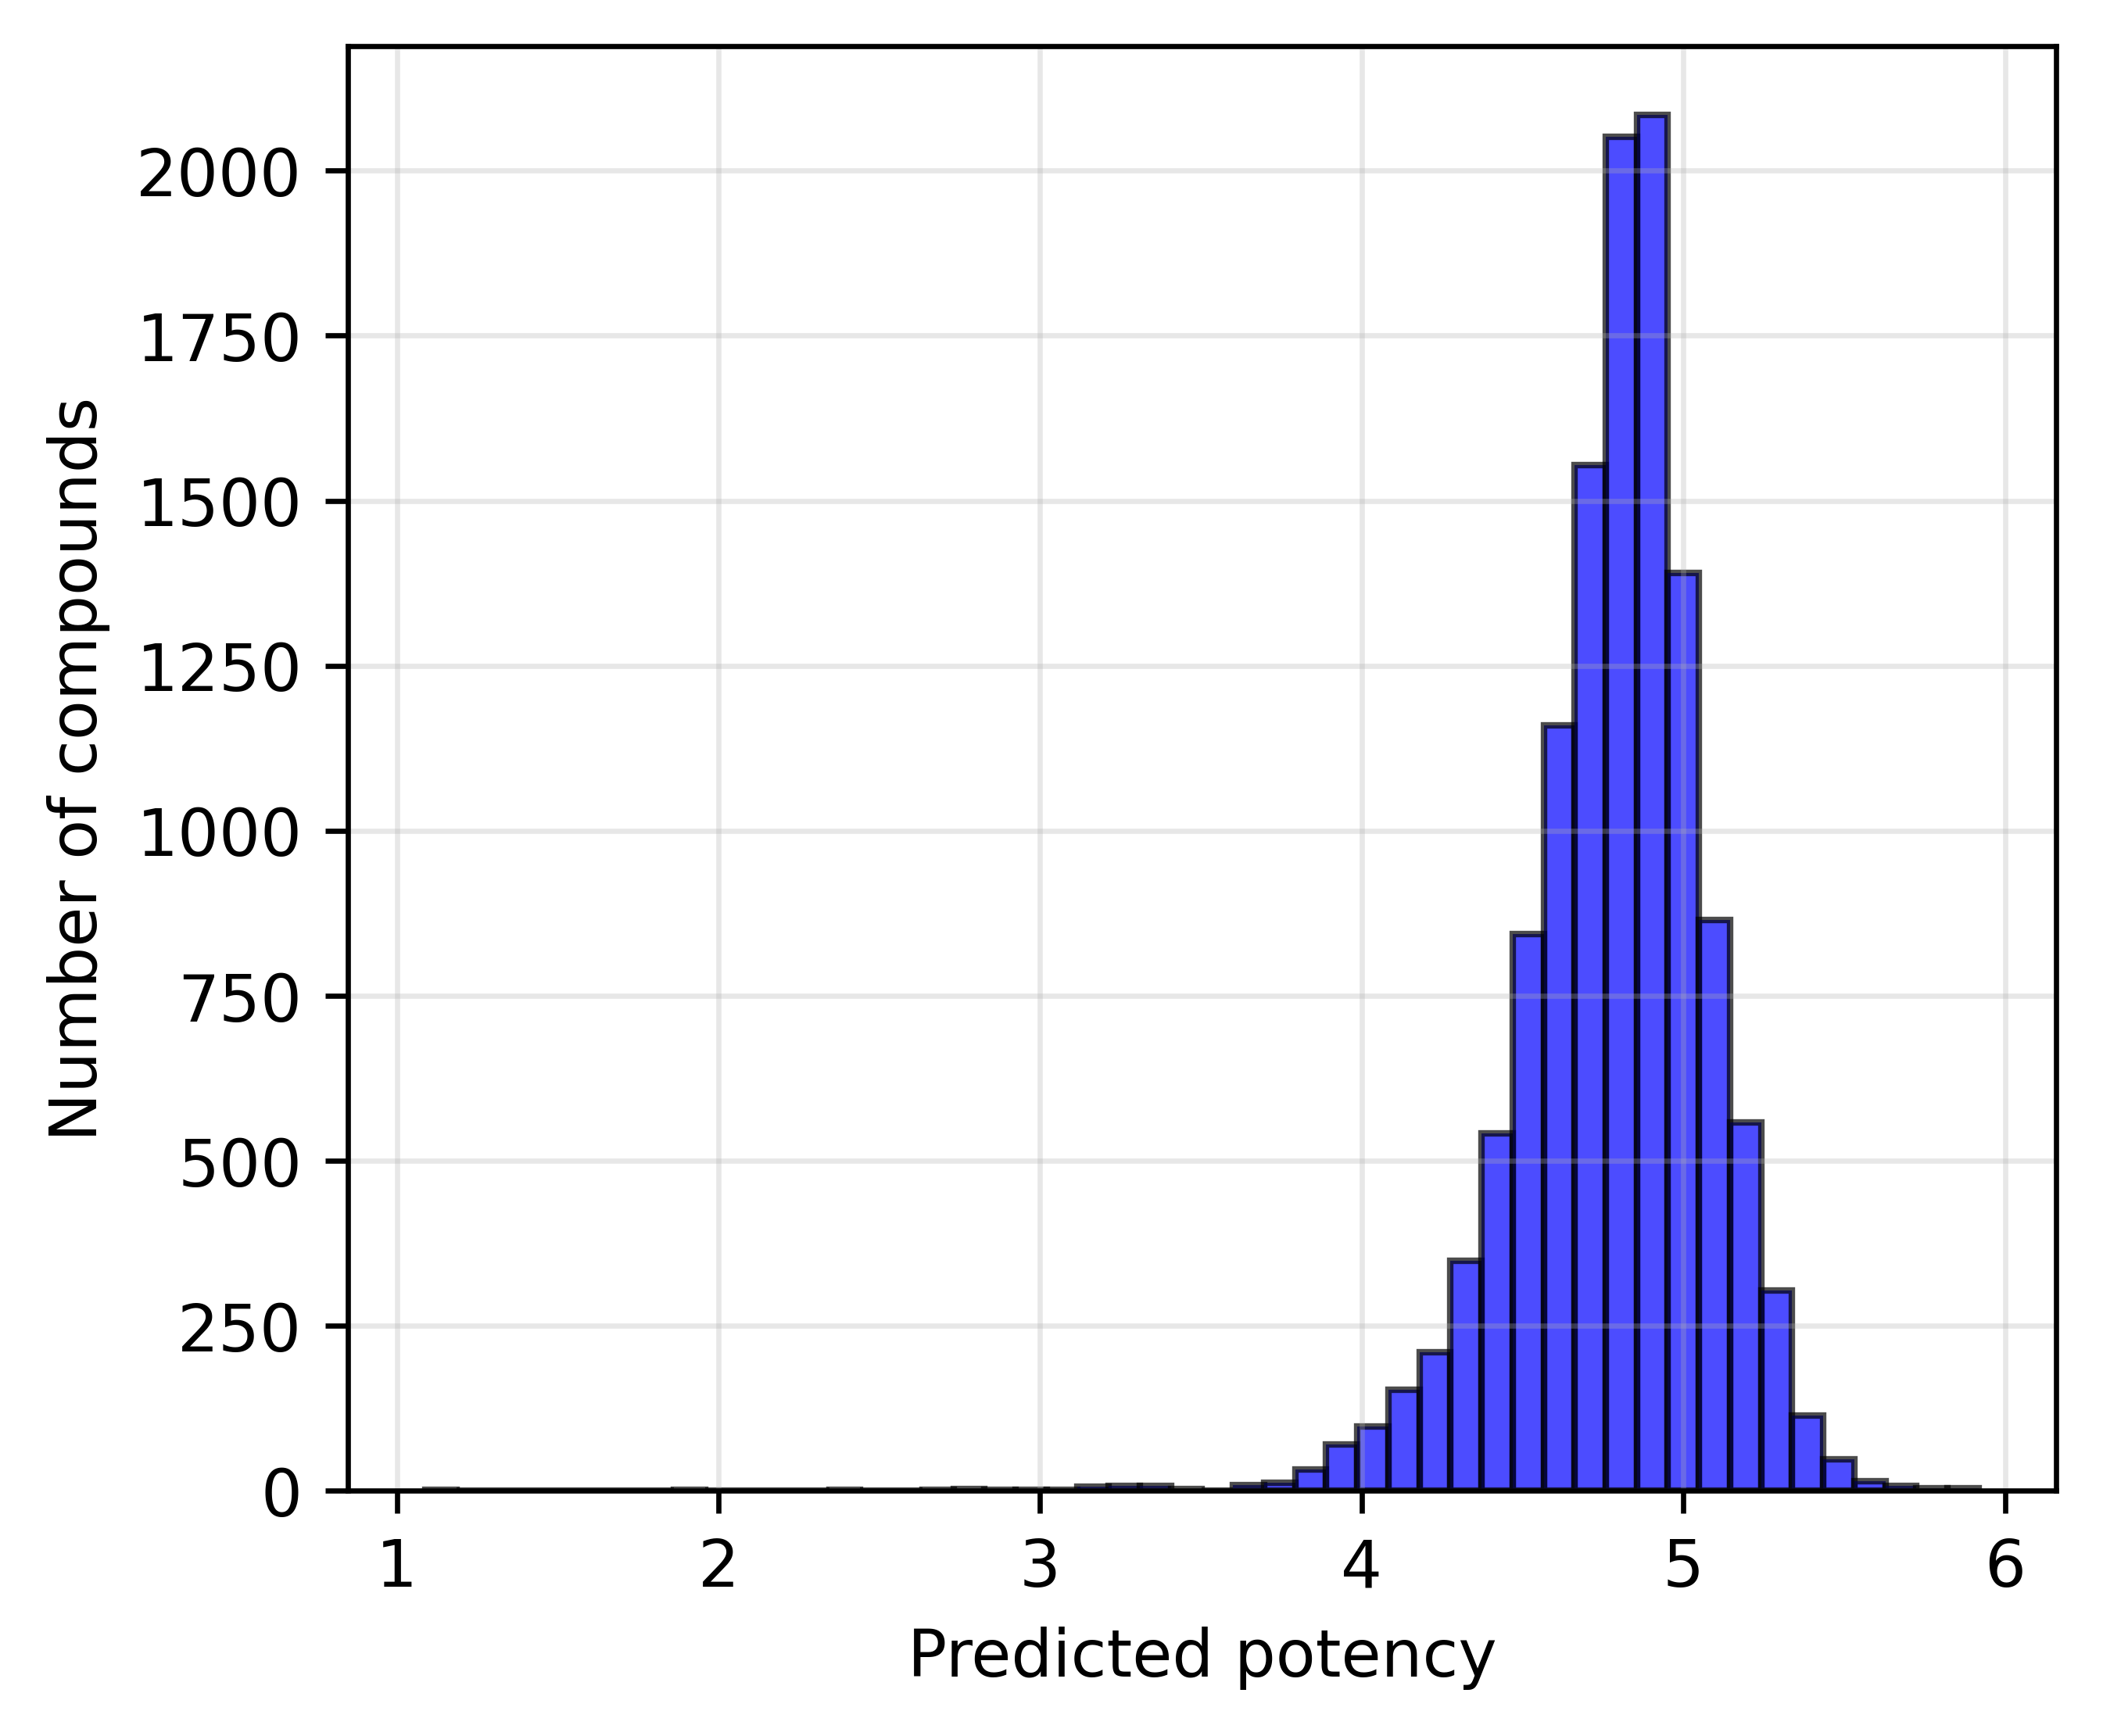

In [145]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.title(f"Virtual screening of custom library ({len(smi_lib)} molecules)", pad=35)
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2) # label='pPotency = 5.0 (minimum)'
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2) # label='pPotency = 6.0 (good)'
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2) # label='pPotency = 7.0 (excellent)'

# Legend on top, outside plot area
#plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(resultsDir + 'YersiniaPestis/YersiniaPestis_validationChemDivDatasets.svg', bbox_inches='tight', dpi=300)
plt.savefig(resultsDir + 'YersiniaPestis/YersiniaPestis_validationChemDivDatasets.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [146]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

High priority (pPotency ≥ 7.0): 0 compounds
Medium priority (6 ≤ pPotency < 7.0): 0 compounds
Low priority (5 ≤ pPotency < 6): 2543 compounds


In [147]:
ChemDivAntiBioticData_final = ChemDivAntiBioticData.iloc[idx].copy()
ChemDivAntiBioticData_final['pPotency_prediction'] = Y1_lib_pred[idx]
ChemDivAntiBioticData_final = ChemDivAntiBioticData_final.filter(
    items=["SMILES", "pPotency_prediction", "clogP"]
)
ChemDivAntiBioticData_final

,SMILES,pPotency_prediction


In [ ]:
molecules = [Chem.MolFromSmiles(smi) for smi in ChemDivAntiBioticData_final.SMILES[:50]]

Draw.MolsToGridImage(molecules, subImgSize=(200,200), molsPerRow=3, useSVG=True)

### Top 20 compounds with higher pPPotency

In [148]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

Top 20 compounds cutoff pPotency: 5.59
Highest predicted pPotency: 5.92
Range of top 20: 5.59 - 5.92


In [149]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
ChemDivAntiBioticData_top20 = ChemDivAntiBioticData.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
ChemDivAntiBioticData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
ChemDivAntiBioticData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
ChemDivAntiBioticData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*50)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*50)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
ChemDivAntiBioticData_top20 = ChemDivAntiBioticData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "IC50 (M)"]
)
ChemDivAntiBioticData_top20

--------------------------------------------------
Top 20 Compounds with Highest Predicted pPotency
--------------------------------------------------

Cutoff Values (20th ranked compound):
  pPotency:    5.592
  IC50:        2.559e-06 M  (2558.72 nM)

Best Values (1st ranked compound):
  pPotency:    5.917
  IC50:        1.209e-06 M  (1209.26 nM)
Range for Top 20 Compounds:
pPotency Range:  5.592 - 5.917

IC50 Range (M):  2.559e-06 - 1.209e-06


,Rank,SMILES,pPotency_prediction,IC50 (M)
2166,1,COc1ccc(C2=NN(C(=S)Nc3ccccc3)C(c3ccc(N(C)C)cc3...,5.917,1.209e-06
10606,2,Cc1onc(-c2ccccc2)c1C(=O)NC1C(=O)N2C1SC(C)(C)C2...,5.863,1.372e-06
4540,3,CC1=NN(C(=S)Nc2ccccc2)C(c2ccccc2)C1,5.833,1.470e-06
2528,4,COc1ccc(OC)c(C2CC(c3ccccc3)=NN2C(=S)Nc2ccccc2)c1,5.824,1.500e-06
56,5,CC1(C)SC2C(NC(=O)Cc3ccccc3)C(=O)N2C1C(=O)[O-],5.807,1.561e-06
4482,6,Fc1ccc(NC(=S)N2N=C(c3ccc(Br)cc3)CC2c2ccc(F)cc2...,5.798,1.591e-06
2111,7,CN(C)c1ccc(/C=N/NC(=S)Nc2cccc(C(=O)O)c2)cc1,5.758,1.746e-06
3792,8,Cc1onc(-c2ccccc2Cl)c1C(=O)NC1C(=O)N2C1SC(C)(C)...,5.725,1.882e-06
2114,9,CC(=NNC(=S)Nc1cccc(C(=O)O)c1)c1ccc(C)cc1,5.682,2.080e-06
4317,10,COc1ccc(C2=NN(c3nc(-c4ccccc4)cs3)C(c3ccco3)C2)cc1,5.664,2.170e-06


 Saved PNG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/YersiniaPestis/YersiniaPestis_predictedCompounds_ChemDivDataset.png
 Saved SVG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/YersiniaPestis/YersiniaPestis_predictedCompounds_ChemDivDataset.svg


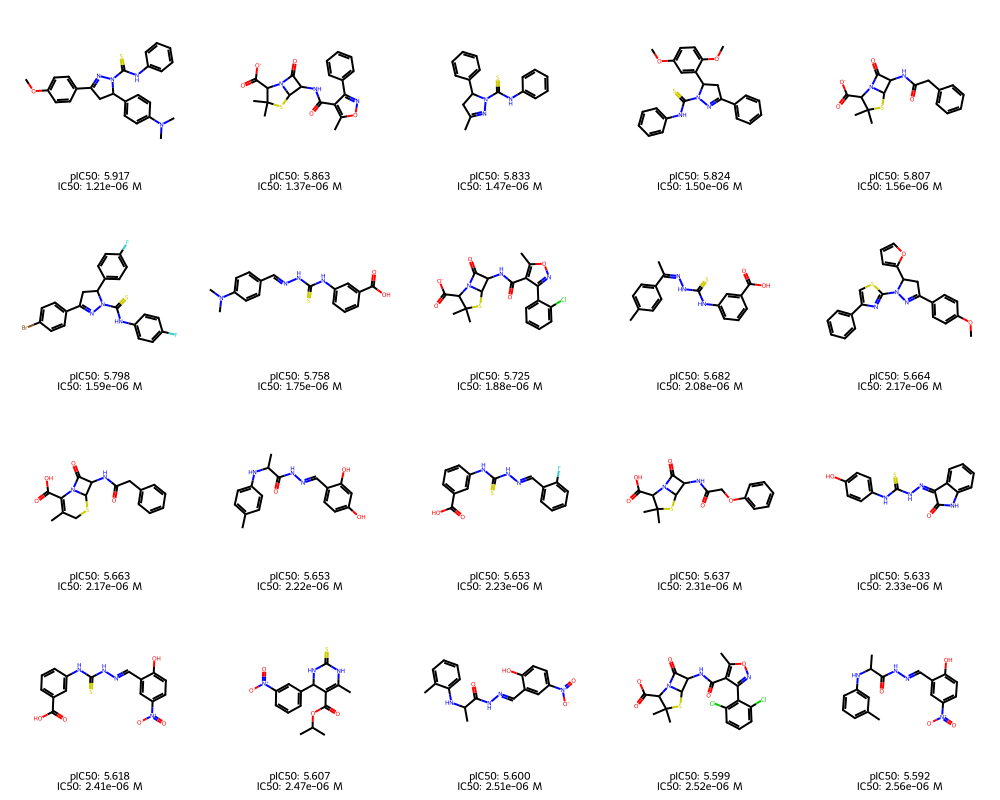

In [150]:
from rdkit import Chem
from rdkit.Chem import Draw
import os
from PIL import Image

# Setup paths
output_dir = resultsDir + 'YersiniaPestis/'
os.makedirs(output_dir, exist_ok=True)

# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in ChemDivAntiBioticData_top20.SMILES[:50]]

# Create legends
legends = []
for idx, row in ChemDivAntiBioticData_top20[:50].iterrows():
    legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = output_dir + 'YersiniaPestis_predictedCompounds_ChemDivDataset.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = output_dir + 'YersiniaPestis_predictedCompounds_ChemDivDataset.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img) 